<a href="https://colab.research.google.com/github/tsholofelo-mokheleli/Healthcare_Access_Inequality/blob/main/01_GHS2025_Data_Preparation_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **GHS 2025: Healthcare Access Inequality in South Africa**

---
## **Data Preparation and Exploratory Data Analysis**

**Study**

**Working title:**  
*Who Is Being Left Behind? Socioeconomic and Geographic Inequalities in Healthcare Access in South Africa*

**Dataset**
Statistics South Africa (Stats SA) General Household Survey (GHS) 2025:
- Person-level dataset
- Household-level dataset

**Purpose of this notebook**
This notebook prepares the GHS 2025 microdata for the analysis of healthcare access inequality in South Africa.

The notebook will:

1. Load and audit the person and household datasets.
2. Examine identifiers and the complex survey design variables.
3. Identify healthcare, socioeconomic, demographic, household, and geographic variables relevant to the study.
4. Assess missingness and response coding.
5. Clean and recode selected variables.
6. Link household characteristics to individuals where analytically appropriate.
7. Construct healthcare access and socioeconomic indicators.
8. Conduct survey-weighted exploratory analysis.
9. Validate and export one analysis-ready dataset for inferential and machine-learning analyses in Notebook 2.

**Research Questions**

**RQ1:** What socioeconomic, demographic and geographic inequalities characterise healthcare access and utilisation in South Africa?

**RQ2:** Which socioeconomic, demographic, geographic and household factors are independently associated with healthcare access disadvantage?

**RQ3:** Which combinations of socioeconomic and geographic characteristics identify population groups experiencing the greatest healthcare access disadvantage?

**Analytical principle**
The GHS uses a complex survey design. Survey weights, primary sampling units (PSUs), and strata will therefore be retained throughout data preparation and incorporated into population-level analyses where methodologically appropriate.

### **Setup and Imports**

In [79]:
import os
import pandas as pd
import numpy as np
import warnings

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

In [13]:
# ============================================================
# PUBLICATION-QUALITY FIGURE SETTINGS
# ============================================================

sns.set_theme(style="white")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 150,
    "savefig.dpi": 600,

    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    "axes.spines.top": False,
    "axes.spines.right": False,

    # Editable text in vector outputs
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

In [14]:
# Global constants for reproducibility
RANDOM_STATE = 42

In [15]:
# Display settings
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [16]:
# ============================================================
# FIGURE EXPORT SETTINGS
# ============================================================

export_png = True
export_pdf = True

out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)


def safe_name(s: str) -> str:
    """Convert figure names into safe filenames."""
    return "".join(
        c if (c.isalnum() or c in "-_") else "_"
        for c in s
    ).strip("_")


def save_figure(fig, name):
    """
    Save publication-quality figure as PNG and/or PDF.
    """
    filename = safe_name(name)

    if export_png:
        fig.savefig(
            os.path.join(out_dir, f"{filename}.png"),
            dpi=600,
            bbox_inches="tight"
        )

    if export_pdf:
        fig.savefig(
            os.path.join(out_dir, f"{filename}.pdf"),
            bbox_inches="tight"
        )


print("Environment ready.")
print(f"Figures will be saved to: {out_dir}/")

Environment ready.
Figures will be saved to: figures/


### **Data Loading and Initial Inspection**

In [17]:
# ============================================================
# LOAD GHS 2025 DATA
# ============================================================

person = pd.read_csv(
    "ghs-2025-person-v1.csv",
    encoding="cp1252",
    low_memory=False
)

household = pd.read_csv(
    "ghs-2025-household-v1.csv",
    encoding="cp1252",
    low_memory=False
)

print(f"Person dataset:    {person.shape[0]:,} rows × {person.shape[1]} columns")
print(f"Household dataset: {household.shape[0]:,} rows × {household.shape[1]} columns")

Person dataset:    67,748 rows × 124 columns
Household dataset: 20,095 rows × 207 columns


### **Initial dataset dimensions**

The GHS 2025 person-level dataset contains **67,748 person records and 124 variables**, while the household-level dataset contains **20,095 household records and 207 variables**.

The larger number of person records is expected because multiple individuals may belong to the same sampled household. Before linking the datasets, the household identifier and expected many-to-one relationship between persons and households will be formally validated.

In [18]:
# ============================================================
# INITIAL STRUCTURAL AUDIT
# ============================================================

def dataset_summary(df, name):
    return pd.DataFrame({
        "Dataset": [name],
        "Rows": [df.shape[0]],
        "Columns": [df.shape[1]],
        "Duplicate rows": [df.duplicated().sum()],
        "Missing cells": [df.isna().sum().sum()],
        "Memory (MB)": [df.memory_usage(deep=True).sum() / 1024**2]
    })


summary = pd.concat([
    dataset_summary(person, "Person"),
    dataset_summary(household, "Household")
], ignore_index=True)

display(summary)

,Dataset,Rows,Columns,Duplicate rows,Missing cells,Memory (MB)
0,Person,67748,124,0,0,502.201
1,Household,20095,207,0,0,237.121


In [19]:
# ============================================================
# HOUSEHOLD IDENTIFIER AUDIT
# ============================================================

HOUSEHOLD_ID = "uqnr"

id_audit = pd.DataFrame({
    "Dataset": ["Person", "Household"],

    "Records": [
        len(person),
        len(household)
    ],

    "Unique households": [
        person[HOUSEHOLD_ID].nunique(dropna=True),
        household[HOUSEHOLD_ID].nunique(dropna=True)
    ],

    "Missing household IDs": [
        person[HOUSEHOLD_ID].isna().sum(),
        household[HOUSEHOLD_ID].isna().sum()
    ],

    "Duplicated household IDs": [
        person[HOUSEHOLD_ID].duplicated().sum(),
        household[HOUSEHOLD_ID].duplicated().sum()
    ]
})

display(id_audit)

,Dataset,Records,Unique households,Missing household IDs,Duplicated household IDs
0,Person,67748,20095,0,47653
1,Household,20095,20095,0,0


In [20]:
# ============================================================
# PERSON-HOUSEHOLD LINKAGE
# ============================================================

person_households = set(
    person[HOUSEHOLD_ID].dropna().unique()
)

household_households = set(
    household[HOUSEHOLD_ID].dropna().unique()
)

missing_households = (
    person_households - household_households
)

households_without_people = (
    household_households - person_households
)

print(
    f"Person households absent from household file: "
    f"{len(missing_households):,}"
)

print(
    f"Household records without person records: "
    f"{len(households_without_people):,}"
)

Person households absent from household file: 0
Household records without person records: 0


In [21]:
# ============================================================
# OBSERVED HOUSEHOLD SIZE
# ============================================================

household_size = (
    person
    .groupby(HOUSEHOLD_ID)
    .size()
    .rename("observed_household_size")
)

display(
    household_size
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
    .to_frame()
)

print("\nLargest observed households:")

display(
    household_size
    .sort_values(ascending=False)
    .head(10)
    .to_frame()
)

,observed_household_size
count,"20,095.000"
mean,3.371
std,2.349
min,1.000
25%,2.000
50%,3.000
75%,5.000
90%,6.000
95%,8.000
99%,11.000



Largest observed households:


,observed_household_size
uqnr,
580101810000001401,24
797148460000014301,20
567100520000002001,20
291103120000012101,19
673100900000015201,19
599130940000014401,18
538101600000012201,18
799150420000027901,18
561101640000005401,18


In [22]:
# ============================================================
# COMPLEX SURVEY DESIGN AUDIT
# ============================================================

person_survey_vars = [
    "person_wgt",
    "psu",
    "stratum",
    "prov",
    "metro",
    "metro_code",
    "geotype"
]

household_survey_vars = [
    "house_wgt",
    "psu",
    "stratum",
    "prov",
    "metro",
    "metro_code",
    "geotype"
]


def audit_variables(df, variables):

    records = []

    for var in variables:

        if var not in df.columns:
            records.append({
                "Variable": var,
                "Present": False,
                "Missing_n": np.nan,
                "Missing_pct": np.nan,
                "Unique": np.nan
            })
            continue

        records.append({
            "Variable": var,
            "Present": True,
            "Missing_n": df[var].isna().sum(),
            "Missing_pct": df[var].isna().mean() * 100,
            "Unique": df[var].nunique(dropna=True)
        })

    return pd.DataFrame(records)


print("PERSON-LEVEL SURVEY VARIABLES")
display(
    audit_variables(person, person_survey_vars)
)

print("\nHOUSEHOLD-LEVEL SURVEY VARIABLES")
display(
    audit_variables(household, household_survey_vars)
)

PERSON-LEVEL SURVEY VARIABLES


,Variable,Present,Missing_n,Missing_pct,Unique
0,person_wgt,True,0,0.000,17566
1,psu,True,0,0.000,3226
2,stratum,True,0,0.000,248
3,prov,True,0,0.000,9
4,metro,True,0,0.000,2
5,metro_code,True,0,0.000,17
6,geotype,True,0,0.000,3



HOUSEHOLD-LEVEL SURVEY VARIABLES


,Variable,Present,Missing_n,Missing_pct,Unique
0,house_wgt,True,0,0.000,4194
1,psu,True,0,0.000,3226
2,stratum,True,0,0.000,248
3,prov,True,0,0.000,9
4,metro,True,0,0.000,2
5,metro_code,True,0,0.000,17
6,geotype,True,0,0.000,3


In [23]:
# ============================================================
# CROSS-FILE CONSISTENCY
# ============================================================

consistency_vars = [
    "psu",
    "stratum",
    "prov",
    "metro",
    "metro_code",
    "geotype"
]

consistency_vars = [
    var for var in consistency_vars
    if var in person.columns
    and var in household.columns
]

check = person[
    [HOUSEHOLD_ID] + consistency_vars
].merge(
    household[
        [HOUSEHOLD_ID] + consistency_vars
    ],
    on=HOUSEHOLD_ID,
    how="left",
    suffixes=("_person", "_household"),
    validate="many_to_one"
)

results = []

for var in consistency_vars:

    p = check[f"{var}_person"]
    h = check[f"{var}_household"]

    match = (
        p.eq(h) |
        (p.isna() & h.isna())
    )

    results.append({
        "Variable": var,
        "Matching_n": match.sum(),
        "Nonmatching_n": (~match).sum(),
        "Agreement_pct": match.mean() * 100
    })

consistency_results = pd.DataFrame(results)

display(consistency_results)

,Variable,Matching_n,Nonmatching_n,Agreement_pct
0,psu,67748,0,100.000
1,stratum,67748,0,100.000
2,prov,67748,0,100.000
3,metro,67748,0,100.000
4,metro_code,67748,0,100.000
5,geotype,67748,0,100.000


### **Data structure and linkage audit**

The person-level dataset contained 67,748 individuals nested within 20,095 sampled households. Household size ranged from 1 to 24 persons, with a median of 3 persons per household.

The household identifier (`uqnr`) was complete in both datasets and unique within the household-level file. All household identifiers represented in the person-level dataset were successfully matched to the household dataset, and no household records lacked corresponding person records.

The complex survey-design variables were complete in both datasets. These included the person and household survey weights, primary sampling unit (`psu`), survey stratum (`stratum`), province, metropolitan status, metropolitan code, and geographic type.

Geographic and survey-design variables shared between the person and household datasets demonstrated 100% agreement across all 67,748 person records. These variables will therefore be retained from the person-level dataset during subsequent linkage to avoid unnecessary duplication.

Although no conventional missing values (`NaN`) were detected in the raw datasets, survey variables may contain explicit response categories representing non-response, uncertainty, inapplicability, or unspecified responses. These categories will be identified and handled during the variable-level audit.

In [24]:
# ============================================================
# SEARCH FOR CANDIDATE ANALYTICAL VARIABLES
# ============================================================

search_terms = [
    # Healthcare
    "hlt", "health", "medi", "clinic", "hospital",
    "fac", "time", "transp",

    # Demographics
    "age", "sex", "population", "marital",

    # Socioeconomic position
    "educ", "employ", "salary", "income", "inc",
    "grant", "exp",

    # Household/material conditions
    "asset", "vehicle", "internet",
    "water", "san", "electric",
    "food",

    # Geography
    "prov", "metro", "geo"
]


def search_variables(df, dataset_name, terms):

    matches = []

    for col in df.columns:

        col_lower = col.lower()

        matched_terms = [
            term for term in terms
            if term.lower() in col_lower
        ]

        if matched_terms:
            matches.append({
                "Dataset": dataset_name,
                "Variable": col,
                "Matched_term": ", ".join(matched_terms),
                "Data_type": str(df[col].dtype),
                "Unique_n": df[col].nunique(dropna=False)
            })

    return pd.DataFrame(matches)


candidate_variables = pd.concat([
    search_variables(
        person,
        "Person",
        search_terms
    ),
    search_variables(
        household,
        "Household",
        search_terms
    )
], ignore_index=True)

display(
    candidate_variables.sort_values(
        ["Dataset", "Variable"]
    )
)

,Dataset,Variable,Matched_term,Data_type,Unique_n
77,Household,HWL_Assets_tumd,asset,object,3
98,Household,Metro_code,metro,object,17
48,Household,SWR_NOTSEPWASTE_TIME,time,object,6
65,Household,fin_compinc,inc,object,6
66,Household,fin_exp,exp,object,15
60,Household,fin_inc_agric,inc,object,3
56,Household,fin_inc_buss,inc,object,3
59,Household,fin_inc_grant,"inc, grant",object,3
63,Household,fin_inc_main,inc,object,9
61,Household,fin_inc_none,inc,object,3


In [25]:
# ============================================================
# CORE HEALTHCARE VARIABLE AUDIT
# ============================================================

health_variables = {
    "Person": [
        "hlt_medi",
        "hlt_genhealth"
    ],

    "Household": [
        "hhw_hltfac",
        "hhw_transp",
        "hhw_time"
    ]
}


def categorical_audit(df, variables, dataset_name):

    for var in variables:

        print("\n" + "=" * 80)
        print(f"{dataset_name.upper()} | {var}")
        print("=" * 80)

        if var not in df.columns:
            print("VARIABLE NOT FOUND")
            continue

        counts = (
            df[var]
            .value_counts(dropna=False)
            .rename("n")
            .to_frame()
        )

        counts["percent"] = (
            counts["n"] / len(df) * 100
        )

        display(counts)


categorical_audit(
    person,
    health_variables["Person"],
    "Person"
)

categorical_audit(
    household,
    health_variables["Household"],
    "Household"
)


PERSON | hlt_medi


,n,percent
hlt_medi,,
2. No,59081,87.207
1. Yes,8542,12.608
3. DO NOT KNOW,124,0.183
9. Unspecified,1,0.001



PERSON | hlt_genhealth


,n,percent
hlt_genhealth,,
3. Good,25603,37.792
2. Very good,19013,28.064
1. Excellent,17863,26.367
4. Fair,4037,5.959
5. Poor,1188,1.754
6. NOT SURE,43,0.063
9. Unspecified,1,0.001



HOUSEHOLD | hhw_hltfac


,n,percent
hhw_hltfac,,
2. Public sector: Clinic,14182,70.575
6. Private sector: Private doctor/specialist,3444,17.139
1. Public sector: Hospital,1311,6.524
4. Private sector: Hospital,392,1.951
5. Private sector: Clinic,321,1.597
9. Private sector: Pharmacy/chemist,268,1.334
3. Public sector: Other in the public sector,44,0.219
7. Private sector: Traditional healer,36,0.179
10. Private sector: Health facility provided by employer,36,0.179



HOUSEHOLD | hhw_transp


,n,percent
hhw_transp,,
1. Walking,9811,48.823
2. Minibus taxi/sedan taxi/bakkie taxi,5585,27.793
5. Own transport,4254,21.169
7. Other means of transport to nearest facility,282,1.403
3. Bus,113,0.562
6. Bicycle/motorcycle,38,0.189
4. Train,10,0.050
9. Unspecified,2,0.010



HOUSEHOLD | hhw_time


,n,percent
hhw_time,,
15â€“29 minutes,9180,45.683
Less than 15 minutes,7707,38.353
30â€“89 minutes,2948,14.670
90 minutes and more,236,1.174
DO NOT KNOW,22,0.109
Unspecified,2,0.010


In [26]:
# ============================================================
# DISABILITY / FUNCTIONAL LIMITATION VARIABLES
# ============================================================

disability_vars = [
    col for col in person.columns
    if col.lower().startswith("dsb")
]

print(
    f"Number of candidate disability variables: "
    f"{len(disability_vars)}"
)

print(disability_vars)

Number of candidate disability variables: 12
['dsb_see', 'dsb_hea', 'dsb_wal', 'dsb_rem', 'dsb_sel', 'dsb_com', 'DSB_ALBINISM', 'dsb_astd_eyeglass', 'dsb_astd_hearaid', 'dsb_astd_walkstick', 'dsb_astd_prosthesis', 'dsb_astd_whechair']


In [27]:
for var in disability_vars:

    print("\n" + "=" * 70)
    print(var)
    print("=" * 70)

    display(
        person[var]
        .value_counts(dropna=False)
        .rename("n")
        .to_frame()
        .assign(
            percent=lambda x:
            x["n"] / len(person) * 100
        )
    )


dsb_see


,n,percent
dsb_see,,
1. No difficulty,57766,85.266
8. Not applicable,5560,8.207
2. Some difficulty,3805,5.616
3. A lot of difficulty,541,0.799
4. Cannot do at all/unable to do,66,0.097
5. DO NOT KNOW,9,0.013
9. Unspecified,1,0.001



dsb_hea


,n,percent
dsb_hea,,
1. No difficulty,60649,89.521
8. Not applicable,5560,8.207
2. Some difficulty,1258,1.857
3. A lot of difficulty,247,0.365
4. Cannot do at all/unable to do,30,0.044
5. DO NOT KNOW,3,0.004
9. Unspecified,1,0.001



dsb_wal


...

,n,percent
dsb_astd_walkstick,,
2. No,61156,90.270
8. Not applicable,5560,8.207
1. Yes,1031,1.522
9. Unspecified,1,0.001



dsb_astd_prosthesis


,n,percent
dsb_astd_prosthesis,,
2. No,62119,91.691
8. Not applicable,5560,8.207
1. Yes,68,0.100
9. Unspecified,1,0.001



dsb_astd_whechair


,n,percent
dsb_astd_whechair,,
2. No,61988,91.498
8. Not applicable,5560,8.207
1. Yes,199,0.294
9. Unspecified,1,0.001


In [28]:
# ============================================================
# DEMOGRAPHIC VARIABLE AUDIT
# ============================================================

demographic_candidates = [
    "age",
    "Sex",
    "Population",
    "hhc_marital",
    "Languages"
]

for var in demographic_candidates:

    if var not in person.columns:
        print(f"{var}: NOT FOUND")
        continue

    print("\n" + "=" * 80)
    print(var)
    print("=" * 80)

    print(
        f"Unique values: "
        f"{person[var].nunique(dropna=False):,}"
    )

    # For low-cardinality categorical variables
    if person[var].nunique(dropna=False) <= 30:

        display(
            person[var]
            .value_counts(dropna=False)
            .rename("n")
            .to_frame()
            .assign(
                percent=lambda x:
                x["n"] / len(person) * 100
            )
        )

    # For continuous/high-cardinality variables
    else:
        display(
            person[var].describe()
        )


age
Unique values: 106


,age
count,67748
unique,106
top,14. 14
freq,1420



Sex
Unique values: 2


,n,percent
Sex,,
2. Female,35161,51.900
1. Male,32587,48.100



Population
Unique values: 4


,n,percent
Population,,
1. African/Black,57689,85.152
2. Coloured,5977,8.822
4. White,3035,4.480
3. Indian/Asian,1047,1.545



hhc_marital
Unique values: 8


,n,percent
hhc_marital,,
7. Single and have never been married/never lived together as husband/wife before,46009,67.912
1. Legally married,11194,16.523
2. Living together like husband and wife/partners,4516,6.666
5. Widowed,3695,5.454
"6. Single, but have lived together with someone as husband/wife before",1004,1.482
3. Divorced,924,1.364
"4. Separated, but still legally married",404,0.596
9. Unspecified,2,0.003



Languages
Unique values: 14


,n,percent
Languages,,
5. IsiZulu,17080,25.211
4. IsiXhosa,11270,16.635
7. Sepedi,6962,10.276
1. Afrikaans,6896,10.179
9. Setswana,6785,10.015
8. Sesotho,5319,7.851
2. English,4138,6.108
13. Xitsonga,3353,4.949
12. Tshivenda,2040,3.011


In [29]:
# ============================================================
# PERSON-LEVEL SOCIOECONOMIC VARIABLE SEARCH
# ============================================================

socioeconomic_terms = [
    "educ",
    "employ",
    "salary",
    "grant",
    "lab_",
    "work",
    "school"
]

socioeconomic_person_vars = search_variables(
    person,
    "Person",
    socioeconomic_terms
)

display(
    socioeconomic_person_vars.sort_values("Variable")
)

,Dataset,Variable,Matched_term,Data_type,Unique_n
0,Person,education,educ,object,32
27,Person,employ_Status1,employ,object,4
28,Person,employ_Status2,employ,object,4
24,Person,lab_accjob,lab_,object,4
14,Person,lab_amount,lab_,object,4
11,Person,lab_bus,lab_,object,3
21,Person,lab_look,lab_,object,3
19,Person,lab_mins,lab_,object,7
25,Person,lab_res_name,lab_,object,17
13,Person,lab_ret,lab_,object,3


In [30]:
# ============================================================
# HOUSEHOLD SOCIOECONOMIC VARIABLE SEARCH
# ============================================================

household_ses_terms = [
    "income",
    "inc",
    "exp",
    "asset",
    "vehicle",
    "internet",
    "water",
    "san",
    "electric",
    "food"
]

household_ses_candidates = search_variables(
    household,
    "Household",
    household_ses_terms
)

display(
    household_ses_candidates.sort_values("Variable")
)

,Dataset,Variable,Matched_term,Data_type,Unique_n
32,Household,HWL_Assets_tumd,asset,object,3
20,Household,fin_compinc,inc,object,6
21,Household,fin_exp,exp,object,15
15,Household,fin_inc_agric,inc,object,3
11,Household,fin_inc_buss,inc,object,3
14,Household,fin_inc_grant,inc,object,3
18,Household,fin_inc_main,inc,object,9
16,Household,fin_inc_none,inc,object,3
17,Household,fin_inc_oth,inc,object,3
13,Household,fin_inc_pen,inc,object,3


In [31]:
# ============================================================
# GEOGRAPHIC VARIABLE AUDIT
# ============================================================

geography_vars = [
    "prov",
    "metro",
    "metro_code",
    "geotype"
]

for var in geography_vars:

    print("\n" + "=" * 80)
    print(var)
    print("=" * 80)

    counts = (
        person[var]
        .value_counts(dropna=False)
        .rename("Unweighted_n")
        .to_frame()
    )

    counts["Unweighted_pct"] = (
        counts["Unweighted_n"] /
        len(person) * 100
    )

    display(counts)


prov


,Unweighted_n,Unweighted_pct
prov,,
7. Gauteng,15710,23.189
5. KwaZulu-Natal,12509,18.464
2. Eastern Cape,8966,13.234
9. Limpopo,7857,11.597
1. Western Cape,6126,9.042
8. Mpumalanga,5471,8.076
6. North West,4255,6.281
4. Free State,3730,5.506
3. Northern Cape,3124,4.611



metro


,Unweighted_n,Unweighted_pct
metro,,
2. Non-metro,42871,63.280
1. Metro,24877,36.720



metro_code


,Unweighted_n,Unweighted_pct
metro_code,,
9,8793,12.979
17,7857,11.597
3,6362,9.391
16,5471,8.076
14,5369,7.925
13,4701,6.939
11,4255,6.281
2,3953,5.835
10,3716,5.485



geotype


,Unweighted_n,Unweighted_pct
geotype,,
1,41126,60.704
2,24408,36.028
3,2214,3.268


In [32]:
# ============================================================
# SURVEY WEIGHT SANITY CHECK
# ============================================================

print("PERSON WEIGHTS")
print("-" * 50)

display(
    person["person_wgt"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .to_frame()
)

print(
    f"\nSum of person weights: "
    f"{person['person_wgt'].sum():,.0f}"
)

print("\nHOUSEHOLD WEIGHTS")
print("-" * 50)

display(
    household["house_wgt"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .to_frame()
)

print(
    f"\nSum of household weights: "
    f"{household['house_wgt'].sum():,.0f}"
)

PERSON WEIGHTS
--------------------------------------------------


,person_wgt
count,"67,748.000"
mean,945.735
std,511.855
min,50.000
1%,144.794
5%,314.728
25%,612.930
50%,866.060
75%,"1,167.440"
95%,"1,858.672"



Sum of person weights: 64,071,685

HOUSEHOLD WEIGHTS
--------------------------------------------------


,house_wgt
count,"20,095.000"
mean,"1,000.955"
std,469.332
min,267.606
1%,337.196
5%,424.860
25%,658.031
50%,939.890
75%,"1,218.566"
95%,"1,782.946"



Sum of household weights: 20,114,196


### **Healthcare access variable audit**

The GHS 2025 contains several variables representing distinct dimensions of healthcare access.

At the person level, `hlt_medi` captures medical aid coverage, while `hlt_genhealth` captures self-reported general health. In the unweighted sample, 87.2% of individuals reported no medical aid and 12.6% reported having medical aid. Self-reported health was predominantly favourable, although a smaller proportion reported fair or poor health.

At the household level, healthcare accessibility is represented through the type of healthcare facility (`hhw_hltfac`), usual transport mode to the facility (`hhw_transp`), and travel time (`hhw_time`). Public clinics constituted the most frequently reported facility category in the unweighted sample. Walking was the most common transport mode, followed by minibus/sedan/bakkie taxi and own transport.

Most households reported reaching the healthcare facility within 30 minutes. However, a subset reported travel times of 30–89 minutes or 90 minutes and longer, providing a direct measure of potential geographic accessibility burden.

These measures represent conceptually distinct dimensions of healthcare access and will initially be analysed separately rather than combined into a single healthcare disadvantage index. Survey-weighted estimates will subsequently be used for population-level inference.

In [33]:
# ============================================================
# CLEAN TEXT ENCODING ARTEFACTS
# ============================================================

def clean_text_encoding(df):
    """
    Correct common encoding artefacts in string columns.
    """
    df = df.copy()

    replacements = {
        "â€“": "–",
        "â€”": "—",
        "â€™": "'",
        "â€œ": '"',
        "â€\x9d": '"'
    }

    object_cols = df.select_dtypes(include="object").columns

    for col in object_cols:
        for bad, good in replacements.items():
            df[col] = df[col].str.replace(
                bad,
                good,
                regex=False
            )

    return df


person = clean_text_encoding(person)
household = clean_text_encoding(household)

print(
    household["hhw_time"]
    .value_counts(dropna=False)
)

hhw_time
15–29 minutes           9180
Less than 15 minutes    7707
30–89 minutes           2948
90 minutes and more      236
DO NOT KNOW               22
Unspecified                2
Name: count, dtype: int64


In [34]:
# ============================================================
# DEFINE NON-SUBSTANTIVE RESPONSE LABELS
# ============================================================

NON_SUBSTANTIVE_TERMS = [
    "DO NOT KNOW",
    "DON'T KNOW",
    "NOT SURE",
    "UNSPECIFIED",
    "NOT APPLICABLE"
]


def is_non_substantive(series):
    """
    Identify explicit non-substantive survey responses.
    """
    s = series.astype(str).str.upper()

    mask = pd.Series(False, index=series.index)

    for term in NON_SUBSTANTIVE_TERMS:
        mask = mask | s.str.contains(
            term,
            regex=False,
            na=False
        )

    return mask

In [35]:
healthcare_audit_vars = {
    "person": [
        "hlt_medi",
        "hlt_genhealth"
    ],
    "household": [
        "hhw_hltfac",
        "hhw_transp",
        "hhw_time"
    ]
}

response_quality = []

for var in healthcare_audit_vars["person"]:

    mask = is_non_substantive(person[var])

    response_quality.append({
        "Dataset": "Person",
        "Variable": var,
        "Total_n": len(person),
        "Non_substantive_n": mask.sum(),
        "Non_substantive_pct": mask.mean() * 100
    })


for var in healthcare_audit_vars["household"]:

    mask = is_non_substantive(household[var])

    response_quality.append({
        "Dataset": "Household",
        "Variable": var,
        "Total_n": len(household),
        "Non_substantive_n": mask.sum(),
        "Non_substantive_pct": mask.mean() * 100
    })


response_quality = pd.DataFrame(response_quality)

display(response_quality)

,Dataset,Variable,Total_n,Non_substantive_n,Non_substantive_pct
0,Person,hlt_medi,67748,125,0.185
1,Person,hlt_genhealth,67748,44,0.065
2,Household,hhw_hltfac,20095,11,0.055
3,Household,hhw_transp,20095,2,0.010
4,Household,hhw_time,20095,24,0.119


In [36]:
# ============================================================
# MEDICAL AID COVERAGE
# ============================================================

person["medical_aid"] = person["hlt_medi"].map({
    "1. Yes": 1,
    "2. No": 0
})

person["no_medical_aid"] = person["hlt_medi"].map({
    "1. Yes": 0,
    "2. No": 1
})


print("Medical aid coverage:")
display(
    person["medical_aid"]
    .value_counts(dropna=False)
    .rename("n")
    .to_frame()
)

print("\nAnalytically missing:")
print(
    f"{person['medical_aid'].isna().sum():,} "
    f"({person['medical_aid'].isna().mean()*100:.2f}%)"
)

Medical aid coverage:


,n
medical_aid,
0.000,59081
1.000,8542
NaN,125



Analytically missing:
125 (0.18%)


In [37]:
# ============================================================
# SELF-REPORTED GENERAL HEALTH
# ============================================================

general_health_map = {
    "1. Excellent": 1,
    "2. Very good": 2,
    "3. Good": 3,
    "4. Fair": 4,
    "5. Poor": 5
}

person["general_health_ord"] = (
    person["hlt_genhealth"]
    .map(general_health_map)
)

# Secondary binary health-need indicator
person["fair_poor_health"] = np.where(
    person["general_health_ord"].notna(),
    (person["general_health_ord"] >= 4).astype(int),
    np.nan
)

display(
    pd.crosstab(
        person["hlt_genhealth"],
        person["general_health_ord"],
        dropna=False
    )
)

general_health_ord,1.000,2.000,3.000,4.000,5.000,NaN
hlt_genhealth,,,,,,
1. Excellent,17863,0,0,0,0,0
2. Very good,0,19013,0,0,0,0
3. Good,0,0,25603,0,0,0
4. Fair,0,0,0,4037,0,0
5. Poor,0,0,0,0,1188,0
6. NOT SURE,0,0,0,0,0,43
9. Unspecified,0,0,0,0,0,1


In [38]:
# ============================================================
# HEALTHCARE FACILITY SECTOR
# ============================================================

def classify_facility_sector(value):

    if pd.isna(value):
        return np.nan

    value_upper = str(value).upper()

    if "DO NOT KNOW" in value_upper:
        return np.nan

    if "UNSPECIFIED" in value_upper:
        return np.nan

    if "PUBLIC SECTOR" in value_upper:
        return "Public"

    if "PRIVATE SECTOR" in value_upper:
        return "Private"

    return np.nan


household["facility_sector"] = (
    household["hhw_hltfac"]
    .apply(classify_facility_sector)
)

display(
    household["facility_sector"]
    .value_counts(dropna=False)
    .rename("n")
    .to_frame()
)

,n
facility_sector,
Public,15537
Private,4547
NaN,11


In [40]:
# ============================================================
# TRAVEL-TIME ACCESSIBILITY
# ============================================================

travel_time_map = {
    "Less than 15 minutes": 1,
    "15–29 minutes": 2,
    "30–89 minutes": 3,
    "90 minutes and more": 4
}

household["travel_time_ord"] = (
    household["hhw_time"]
    .map(travel_time_map)
)

household["high_travel_burden"] = np.where(
    household["travel_time_ord"].notna(),
    (household["travel_time_ord"] >= 3).astype(int),
    np.nan
)

display(
    pd.crosstab(
        household["hhw_time"],
        household["high_travel_burden"],
        margins=True,
        dropna=False
    )
)

high_travel_burden,0.000,1.000,NaN,All
hhw_time,,,,
15–29 minutes,9180,0,0,9180
30–89 minutes,0,2948,0,2948
90 minutes and more,0,236,0,236
DO NOT KNOW,0,0,22,22
Less than 15 minutes,7707,0,0,7707
Unspecified,0,0,2,2
All,16887,3184,0,20095


In [41]:
# ============================================================
# TRANSPORT ACCESS
# ============================================================

transport_map = {
    "1. Walking":
        "Walking",

    "2. Minibus taxi/sedan taxi/bakkie taxi":
        "Public/shared transport",

    "3. Bus":
        "Public/shared transport",

    "4. Train":
        "Public/shared transport",

    "5. Own transport":
        "Own transport",

    "6. Bicycle/motorcycle":
        "Other",

    "7. Other means of transport to nearest facility":
        "Other"
}

household["transport_group"] = (
    household["hhw_transp"]
    .map(transport_map)
)

display(
    household["transport_group"]
    .value_counts(dropna=False)
    .rename("n")
    .to_frame()
)

,n
transport_group,
Walking,9811
Public/shared transport,5708
Own transport,4254
Other,320
NaN,2


In [42]:
# ============================================================
# HEALTHCARE VARIABLE VALIDATION
# ============================================================

derived_health_vars = pd.DataFrame({
    "Variable": [
        "medical_aid",
        "no_medical_aid",
        "general_health_ord",
        "fair_poor_health",
        "facility_sector",
        "travel_time_ord",
        "high_travel_burden",
        "transport_group"
    ],

    "Level": [
        "Person",
        "Person",
        "Person",
        "Person",
        "Household",
        "Household",
        "Household",
        "Household"
    ],

    "Role": [
        "Healthcare coverage",
        "Healthcare disadvantage",
        "Health status / need",
        "Health status / need",
        "Healthcare sector",
        "Geographic accessibility",
        "Geographic accessibility",
        "Transport accessibility"
    ]
})

display(derived_health_vars)

,Variable,Level,Role
0,medical_aid,Person,Healthcare coverage
1,no_medical_aid,Person,Healthcare disadvantage
2,general_health_ord,Person,Health status / need
3,fair_poor_health,Person,Health status / need
4,facility_sector,Household,Healthcare sector
5,travel_time_ord,Household,Geographic accessibility
6,high_travel_burden,Household,Geographic accessibility
7,transport_group,Household,Transport accessibility


### **Social Determinants of healthcare Access**

```
SOCIAL POSITION
├── Age
├── Sex
├── Population group
├── Education
└── Marital status
        │
        ▼
SOCIOECONOMIC POSITION
├── Employment
├── Household income
├── Social grants
└── Household wealth/assets
        │
        ▼
MATERIAL & GEOGRAPHIC CONTEXT
├── Household size
├── Food security
├── Housing/services
├── Province
├── Metro/non-metro
└── Geotype
        │
        ▼
HEALTHCARE ACCESS
├── Medical aid
├── Facility sector
├── Transport
└── Travel burden
```



In [43]:
# ============================================================
# PERSON-LEVEL SOCIAL DETERMINANT VARIABLE INVENTORY
# ============================================================

person_terms = [
    "age",
    "sex",
    "population",
    "marital",
    "educ",
    "school",
    "employ",
    "work",
    "lab_",
    "salary",
    "grant",
    "language"
]

person_candidates = search_variables(
    person,
    "Person",
    person_terms
)

display(
    person_candidates
    .sort_values("Variable")
    .reset_index(drop=True)
)

,Dataset,Variable,Matched_term,Data_type,Unique_n
0,Person,Age_grp1,age,object,16
1,Person,Languages,"age, language",object,14
2,Person,Population,population,object,4
3,Person,Sex,sex,object,2
4,Person,age,age,object,106
5,Person,age_grp1,age,int64,16
6,Person,education,educ,object,32
7,Person,employ_Status1,employ,object,4
8,Person,employ_Status2,employ,object,4
9,Person,hhc_marital,marital,object,8


In [44]:
# ============================================================
# DEMOGRAPHIC VARIABLE AUDIT
# ============================================================

demographic_vars = [
    "age",
    "Sex",
    "Population",
    "hhc_marital",
    "Languages"
]

for var in demographic_vars:

    if var not in person.columns:
        print(f"\n{var}: NOT FOUND")
        continue

    print("\n" + "=" * 80)
    print(var)
    print("=" * 80)

    print(f"Data type: {person[var].dtype}")
    print(f"Unique values: {person[var].nunique(dropna=False):,}")

    if person[var].nunique(dropna=False) <= 30:

        counts = (
            person[var]
            .value_counts(dropna=False)
            .rename("n")
            .to_frame()
        )

        counts["percent"] = (
            counts["n"] / len(person) * 100
        )

        display(counts)

    else:

        display(
            person[var]
            .describe(
                percentiles=[
                    0.01,
                    0.05,
                    0.25,
                    0.50,
                    0.75,
                    0.95,
                    0.99
                ]
            )
            .to_frame()
        )


age
Data type: object
Unique values: 106


,age
count,67748
unique,106
top,14. 14
freq,1420



Sex
Data type: object
Unique values: 2


,n,percent
Sex,,
2. Female,35161,51.900
1. Male,32587,48.100



Population
Data type: object
Unique values: 4


,n,percent
Population,,
1. African/Black,57689,85.152
2. Coloured,5977,8.822
4. White,3035,4.480
3. Indian/Asian,1047,1.545



hhc_marital
Data type: object
Unique values: 8


,n,percent
hhc_marital,,
7. Single and have never been married/never lived together as husband/wife before,46009,67.912
1. Legally married,11194,16.523
2. Living together like husband and wife/partners,4516,6.666
5. Widowed,3695,5.454
"6. Single, but have lived together with someone as husband/wife before",1004,1.482
3. Divorced,924,1.364
"4. Separated, but still legally married",404,0.596
9. Unspecified,2,0.003



Languages
Data type: object
Unique values: 14


,n,percent
Languages,,
5. IsiZulu,17080,25.211
4. IsiXhosa,11270,16.635
7. Sepedi,6962,10.276
1. Afrikaans,6896,10.179
9. Setswana,6785,10.015
8. Sesotho,5319,7.851
2. English,4138,6.108
13. Xitsonga,3353,4.949
12. Tshivenda,2040,3.011


In [48]:
# ============================================================
# AGE VALIDITY CHECK
# ============================================================

if "age" in person.columns:
    person["age_numeric"] = person["age"].astype(str).str.extract(r'^(\d+)').astype(float)

    print(f"Minimum age: {person['age_numeric'].min():.0f}")
    print(f"Maximum age: {person['age_numeric'].max():.0f}")

    print(
        "Records aged < 0:",
        (person["age_numeric"] < 0).sum()
    )

    print(
        "Records aged > 110:",
        (person["age_numeric"] > 110).sum()
    )

    print(
        "Records with missing (NaN) age after conversion:",
        person['age_numeric'].isna().sum()
    )

    print("\nAge percentiles:")

    display(
        person["age_numeric"]
        .describe(
            percentiles=[
                .01, .05, .10, .25,
                .50, .75, .90, .95, .99
            ]
        )
        .to_frame()
    )

Minimum age: 0
Maximum age: 105
Records aged < 0: 0
Records aged > 110: 0
Records with missing (NaN) age after conversion: 0

Age percentiles:


,age_numeric
count,"67,748.000"
mean,30.848
std,20.924
min,0.000
1%,0.000
5%,3.000
10%,5.000
25%,13.000
50%,28.000
75%,46.000


In [49]:
# ============================================================
# HOUSEHOLD SOCIOECONOMIC VARIABLE INVENTORY
# ============================================================

household_terms = [
    "income",
    "inc",
    "exp",
    "asset",
    "vehicle",
    "food",
    "hun",
    "water",
    "san",
    "toilet",
    "electric",
    "internet",
    "dwelling",
    "house"
]

household_candidates = search_variables(
    household,
    "Household",
    household_terms
)

display(
    household_candidates
    .sort_values("Variable")
    .reset_index(drop=True)
)

,Dataset,Variable,Matched_term,Data_type,Unique_n
0,Household,HWL_Assets_tumd,asset,object,3
1,Household,fin_compinc,inc,object,6
2,Household,fin_exp,exp,object,15
3,Household,fin_inc_agric,inc,object,3
4,Household,fin_inc_buss,inc,object,3
5,Household,fin_inc_grant,inc,object,3
6,Household,fin_inc_main,inc,object,9
7,Household,fin_inc_none,inc,object,3
8,Household,fin_inc_oth,inc,object,3
9,Household,fin_inc_pen,inc,object,3


In [50]:
# ============================================================
# HOUSEHOLD ASSET INVENTORY
# ============================================================

asset_vars = [
    col for col in household.columns
    if "asset" in col.lower()
]

print(
    f"Number of candidate asset variables: "
    f"{len(asset_vars)}"
)

for i, var in enumerate(asset_vars, 1):
    print(f"{i:>2}. {var}")

Number of candidate asset variables: 24
 1. hwl_assets_tv
 2. hwl_assets_pool
 3. hwl_assets_dvd
 4. hwl_assets_paytv
 5. hwl_assets_ac
 6. hwl_assets_comp
 7. hwl_assets_vac
 8. hwl_assets_dishw
 9. hwl_assets_washm
10. HWL_Assets_tumd
11. hwl_assets_freezer
12. hwl_assets_fridge
13. hwl_assets_estove
14. hwl_assets_microw
15. hwl_assets_sink
16. hwl_assets_secure
17. hwl_assets_hometh
18. hwl_assets_geyser
19. hwl_assets_solarg
20. hwl_assets_solarp
21. hwl_assets_rainwtnk
22. hwl_assets_borehole
23. hwl_assets_radio
24. hwl_assets_Gstove


In [51]:
# ============================================================
# ASSET RESPONSE CODING
# ============================================================

for var in asset_vars:

    print("\n" + "=" * 70)
    print(var)
    print("=" * 70)

    display(
        household[var]
        .value_counts(dropna=False)
        .rename("n")
        .to_frame()
        .assign(
            percent=lambda x:
            x["n"] / len(household) * 100
        )
    )


hwl_assets_tv


,n,percent
hwl_assets_tv,,
1. Yes,15568,77.472
2. No,4522,22.503
9. Unspecified,5,0.025



hwl_assets_pool


,n,percent
hwl_assets_pool,,
2. No,19481,96.945
1. Yes,609,3.031
9. Unspecified,5,0.025



hwl_assets_dvd


...

,n,percent
hwl_assets_borehole,,
2. No,19252,95.805
1. Yes,838,4.170
9. Unspecified,5,0.025



hwl_assets_radio


,n,percent
hwl_assets_radio,,
2. No,13884,69.092
1. Yes,6206,30.883
9. Unspecified,5,0.025



hwl_assets_Gstove


,n,percent
hwl_assets_Gstove,,
2. No,13931,69.326
1. Yes,6159,30.649
9. Unspecified,5,0.025


In [52]:
# ============================================================
# GEOGRAPHIC CONTEXT
# ============================================================

geography_vars = [
    "prov",
    "metro",
    "metro_code",
    "geotype"
]

for var in geography_vars:

    print("\n" + "=" * 80)
    print(var)
    print("=" * 80)

    counts = (
        person[var]
        .value_counts(dropna=False)
        .rename("Unweighted_n")
        .to_frame()
    )

    counts["Unweighted_pct"] = (
        counts["Unweighted_n"] /
        len(person) * 100
    )

    display(counts)


prov


,Unweighted_n,Unweighted_pct
prov,,
7. Gauteng,15710,23.189
5. KwaZulu-Natal,12509,18.464
2. Eastern Cape,8966,13.234
9. Limpopo,7857,11.597
1. Western Cape,6126,9.042
8. Mpumalanga,5471,8.076
6. North West,4255,6.281
4. Free State,3730,5.506
3. Northern Cape,3124,4.611



metro


,Unweighted_n,Unweighted_pct
metro,,
2. Non-metro,42871,63.280
1. Metro,24877,36.720



metro_code


,Unweighted_n,Unweighted_pct
metro_code,,
9,8793,12.979
17,7857,11.597
3,6362,9.391
16,5471,8.076
14,5369,7.925
13,4701,6.939
11,4255,6.281
2,3953,5.835
10,3716,5.485



geotype


,Unweighted_n,Unweighted_pct
geotype,,
1,41126,60.704
2,24408,36.028
3,2214,3.268


In [53]:
# ============================================================
# SURVEY WEIGHT SANITY CHECK
# ============================================================

print("=" * 70)
print("PERSON WEIGHTS")
print("=" * 70)

display(
    person["person_wgt"]
    .describe(
        percentiles=[
            .01, .05, .25, .50,
            .75, .95, .99
        ]
    )
    .to_frame()
)

person_population = person["person_wgt"].sum()

print(
    f"\nWeighted population represented: "
    f"{person_population:,.0f}"
)


print("\n" + "=" * 70)
print("HOUSEHOLD WEIGHTS")
print("=" * 70)

display(
    household["house_wgt"]
    .describe(
        percentiles=[
            .01, .05, .25, .50,
            .75, .95, .99
        ]
    )
    .to_frame()
)

household_population = household["house_wgt"].sum()

print(
    f"\nWeighted households represented: "
    f"{household_population:,.0f}"
)

PERSON WEIGHTS


,person_wgt
count,"67,748.000"
mean,945.735
std,511.855
min,50.000
1%,144.794
5%,314.728
25%,612.930
50%,866.060
75%,"1,167.440"
95%,"1,858.672"



Weighted population represented: 64,071,685

HOUSEHOLD WEIGHTS


,house_wgt
count,"20,095.000"
mean,"1,000.955"
std,469.332
min,267.606
1%,337.196
5%,424.860
25%,658.031
50%,939.890
75%,"1,218.566"
95%,"1,782.946"



Weighted households represented: 20,114,196


In [54]:
# ============================================================
# WEIGHTED PROPORTION FUNCTION
# ============================================================

def weighted_proportions(df, variable, weight):

    temp = df[[variable, weight]].copy()

    temp = temp.dropna(
        subset=[variable, weight]
    )

    result = (
        temp
        .groupby(variable, observed=True)[weight]
        .sum()
        .rename("weighted_n")
        .reset_index()
    )

    total_weight = result["weighted_n"].sum()

    result["weighted_pct"] = (
        result["weighted_n"] /
        total_weight * 100
    )

    return result

In [55]:
province_weighted = weighted_proportions(
    person,
    variable="prov",
    weight="person_wgt"
)

display(province_weighted)

,prov,weighted_n,weighted_pct
0,1. Western Cape,"7,645,549.386",11.933
1,2. Eastern Cape,"6,530,280.279",10.192
2,3. Northern Cape,"1,335,199.552",2.084
3,4. Free State,"3,079,141.790",4.806
4,5. KwaZulu-Natal,"12,231,106.359",19.090
5,6. North West,"4,386,467.044",6.846
6,7. Gauteng,"17,401,837.410",27.160
7,8. Mpumalanga,"5,099,126.827",7.958
8,9. Limpopo,"6,362,976.820",9.931


In [56]:
medical_aid_weighted = weighted_proportions(
    person.loc[
        person["medical_aid"].notna()
    ],
    variable="medical_aid",
    weight="person_wgt"
)

display(medical_aid_weighted)

,medical_aid,weighted_n,weighted_pct
0,0.000,"53,971,958.075",84.421
1,1.000,"9,959,699.224",15.579


In [57]:
# ============================================================
# WEIGHTED VS UNWEIGHTED MEDICAL AID COVERAGE
# ============================================================

valid_medical = person[
    person["medical_aid"].notna()
].copy()

unweighted_coverage = (
    valid_medical["medical_aid"].mean() * 100
)

weighted_coverage = (
    np.average(
        valid_medical["medical_aid"],
        weights=valid_medical["person_wgt"]
    ) * 100
)

comparison = pd.DataFrame({
    "Estimate": [
        "Unweighted sample",
        "Survey weighted"
    ],
    "Medical aid coverage (%)": [
        unweighted_coverage,
        weighted_coverage
    ]
})

display(comparison.round(2))

,Estimate,Medical aid coverage (%)
0,Unweighted sample,12.630
1,Survey weighted,15.580


In [58]:
# ============================================================
# EDUCATION AND EMPLOYMENT AUDIT
# ============================================================

person_ses_vars = [
    "education",
    "employ_Status1",
    "employ_Status2",
    "soc_grant"
]

for var in person_ses_vars:

    print("\n" + "=" * 80)
    print(var)
    print("=" * 80)

    if var not in person.columns:
        print("VARIABLE NOT FOUND")
        continue

    counts = (
        person[var]
        .value_counts(dropna=False)
        .rename("n")
        .to_frame()
    )

    counts["percent"] = (
        counts["n"] / len(person) * 100
    )

    display(counts)


education


,n,percent
education,,
12. GRADE 12/STANDARD 10/FORM 5/NATIONAL SENIOR CERTIFICATE/MATRIC/ NCV LEVEL 4 /OCCUPATIONAL CERTIFICATE – NQF LEVEL 4,14850,21.919
98. NO SCHOOLING,8652,12.771
11. GRADE 11/STANDARD 9/FORM 4/NCV LEVEL 3/OCCUPATIONAL CERTIFICATE – NQF LEV EL 3,6566,9.692
10. GRADE 10/STANDARD 8/FORM 3/NCV LEVEL 2/OCCUPATIONAL CERTIFICATE – NQF LEV EL 2,5854,8.641
9. GRADE 9/STANDARD 7/FORM 2/ABET/AET 4/NCV LEVEL 1/OCCUPATIONAL CERTIFICATE - NQF LEVEL 1,4187,6.180
8. GRADE 8/STANDARD 6/FORM 1,3762,5.553
7. GRADE 7/STANDARD 5/ABET/AET 3,3435,5.070
6. GRADE 6/STANDARD 4,2500,3.690
4. GRADE 4/STANDARD 2,2084,3.076



employ_Status1


,n,percent
employ_Status1,,
9. Unspecified,20877,30.816
8. Not applicable,18514,27.328
1. Employed,18363,27.105
2. Unemployed,9994,14.752



employ_Status2


,n,percent
employ_Status2,,
3. Not economically active,20877,30.816
8. Not applicable,18514,27.328
1. Employed,18363,27.105
2. Unemployed,9994,14.752



soc_grant


,n,percent
soc_grant,,
2. No,37498,55.349
1. Yes,30066,44.379
3. Do not know,182,0.269
9. Unspecified,2,0.003


In [59]:
# ============================================================
# HOUSEHOLD INCOME AND EXPENDITURE AUDIT
# ============================================================

financial_vars = [
    "totmhinc",
    "fin_exp",
    "fin_reqinc",
    "fin_compinc"
]

for var in financial_vars:

    print("\n" + "=" * 80)
    print(var)
    print("=" * 80)

    if var not in household.columns:
        print("VARIABLE NOT FOUND")
        continue

    print(f"Data type: {household[var].dtype}")
    print(
        f"Unique values: "
        f"{household[var].nunique(dropna=False):,}"
    )

    # Show most frequent values/categories
    display(
        household[var]
        .value_counts(dropna=False)
        .head(30)
        .rename("n")
        .to_frame()
        .assign(
            percent=lambda x:
            x["n"] / len(household) * 100
        )
    )


totmhinc
Data type: object
Unique values: 3,604


,n,percent
totmhinc,,
1990. 1990,817,4.066
9999999. Unspecified,432,2.150
350. 350,347,1.727
2010. 2010,271,1.349
21583. 21583,270,1.344
4000. 4000,255,1.269
0. 0,240,1.194
5257. 5257,228,1.135
5000. 5000,227,1.130



fin_exp
Data type: object
Unique values: 15


,n,percent
fin_exp,,
R2 500–R4 999,5655,28.141
R5 000–R9 999,3980,19.806
R1 800–R2 499,3052,15.188
R10 000–R19 999,1937,9.639
R1 200–R1 799,1562,7.773
R20 000–R39 999,1150,5.723
R800–R1 199,1030,5.126
R400–R799,605,3.011
R40 000 or more,435,2.165



fin_reqinc
Data type: object
Unique values: 275


,n,percent
fin_reqinc,,
5000. 5000,2714,13.506
10000. 10000,1871,9.311
3000. 3000,1399,6.962
2000. 2000,1342,6.678
20000. 20000,1073,5.340
15000. 15000,956,4.757
6000. 6000,949,4.723
4000. 4000,895,4.454
8000. 8000,770,3.832



fin_compinc
Data type: object
Unique values: 6


,n,percent
fin_compinc,,
3. More or less the same,7099,35.327
4. Lower,6132,30.515
2. Higher,3570,17.766
5. Much lower,2534,12.610
1. Much higher,756,3.762
9. Unspecified,4,0.020


In [60]:
# ============================================================
# TOTAL MONTHLY HOUSEHOLD INCOME STRUCTURE
# ============================================================

print("Sample values:")
display(
    household["totmhinc"]
    .drop_duplicates()
    .head(30)
    .to_frame()
)

print("\nMost frequent values:")
display(
    household["totmhinc"]
    .value_counts(dropna=False)
    .head(20)
    .rename("n")
    .to_frame()
)

print("\nLast values after alphabetical sorting:")
display(
    household["totmhinc"]
    .drop_duplicates()
    .sort_values()
    .tail(30)
    .to_frame()
)

Sample values:


,totmhinc
0,1990. 1990
2,35417. 35417
3,55010. 55010
4,20000. 20000
7,3998. 3998
8,500. 500
9,12695. 12695
10,6937. 6937
11,600. 600
12,4010. 4010



Most frequent values:


,n
totmhinc,
1990. 1990,817
9999999. Unspecified,432
350. 350,347
2010. 2010,271
21583. 21583,270
4000. 4000,255
0. 0,240
5257. 5257,228
5000. 5000,227



Last values after alphabetical sorting:


,totmhinc
3057,985. 985
14153,9850. 9850
19652,9860. 9860
9925,9868. 9868
11936,9870. 9870
11231,9880. 9880
737,98902. 98902
18311,9898. 9898
1489,9899. 9899
5600,9900. 9900


In [61]:
# ============================================================
# HOUSEHOLD INCOME SOURCE AUDIT
# ============================================================

income_source_vars = [
    "fin_inc_sal",
    "fin_inc_grant",
    "fin_inc_pen",
    "fin_inc_rem",
    "fin_inc_buss",
    "fin_inc_agric",
    "fin_inc_oth",
    "fin_inc_none"
]

for var in income_source_vars:

    if var not in household.columns:
        continue

    print("\n" + "=" * 70)
    print(var)
    print("=" * 70)

    display(
        household[var]
        .value_counts(dropna=False)
        .rename("n")
        .to_frame()
        .assign(
            percent=lambda x:
            x["n"] / len(household) * 100
        )
    )


fin_inc_sal


,n,percent
fin_inc_sal,,
1. Yes,11623,57.840
2. No,8471,42.155
9. Unspecified,1,0.005



fin_inc_grant


,n,percent
fin_inc_grant,,
1. Yes,11909,59.263
2. No,8185,40.732
9. Unspecified,1,0.005



fin_inc_pen


...

,n,percent
fin_inc_agric,,
2. No,20053,99.791
1. Yes,41,0.204
9. Unspecified,1,0.005



fin_inc_oth


,n,percent
fin_inc_oth,,
2. No,19553,97.303
1. Yes,541,2.692
9. Unspecified,1,0.005



fin_inc_none


,n,percent
fin_inc_none,,
2. No,19854,98.801
1. Yes,240,1.194
9. Unspecified,1,0.005


In [62]:
# ============================================================
# FOOD SECURITY AUDIT
# ============================================================

food_vars = [
    col for col in household.columns
    if col.lower().startswith("fsd_")
]

print(
    f"Food-security variables identified: "
    f"{len(food_vars)}"
)

print(food_vars)

for var in food_vars:

    print("\n" + "=" * 70)
    print(var)
    print("=" * 70)

    display(
        household[var]
        .value_counts(dropna=False)
        .rename("n")
        .to_frame()
        .assign(
            percent=lambda x:
            x["n"] / len(household) * 100
        )
    )

Food-security variables identified: 14
['fsd_hung_adult', 'fsd_hung_child', 'fsd_worried', 'fsd_healthy', 'fsd_fewfoods', 'fsd_fewfoods_days', 'fsd_skipped', 'fsd_skipped_days', 'fsd_ateless', 'fsd_ateless_days', 'fsd_ranout', 'fsd_ranout_days', 'fsd_hungry', 'fsd_whlday']

fsd_hung_adult


,n,percent
fsd_hung_adult,,
1. Never,16108,80.159
3. Sometimes,2035,10.127
2. Seldom,1256,6.250
4. Often,389,1.936
6. Not applicable (no adults in household),168,0.836
5. Always,137,0.682
9. Unspecified,2,0.010



fsd_hung_child


,n,percent
fsd_hung_child,,
1. Never,9284,46.201
6. Not applicable (no children in household),8705,43.319
3. Sometimes,1167,5.807
2. Seldom,688,3.424
4. Often,190,0.946
5. Always,59,0.294
9. Unspecified,2,0.010



fsd_worried


...

,n,percent
fsd_ranout_days,,
8. Not applicable,16478,82.000
1. Yes,1882,9.366
2. No,1735,8.634



fsd_hungry


,n,percent
fsd_hungry,,
2. No,17348,86.330
1. Yes,2723,13.551
9. Unspecified,24,0.119



fsd_whlday


,n,percent
fsd_whlday,,
2. No,18064,89.893
1. Yes,2017,10.037
9. Unspecified,14,0.070


In [63]:
# ============================================================
# HOUSEHOLD COMPOSITION VARIABLE SEARCH
# ============================================================

composition_terms = [
    "hhsize",
    "hh_size",
    "size",
    "member",
    "child",
    "adult",
    "depend"
]

composition_candidates = search_variables(
    household,
    "Household",
    composition_terms
)

display(
    composition_candidates
    .sort_values("Variable")
    .reset_index(drop=True)
)

,Dataset,Variable,Matched_term,Data_type,Unique_n
0,Household,fsd_hung_adult,adult,object,7
1,Household,fsd_hung_child,child,object,7


In [64]:
# ============================================================
# ASSET SUITABILITY FOR WEALTH INDEX
# ============================================================

asset_summary = []

for var in asset_vars:

    yes_mask = (
        household[var]
        .astype(str)
        .str.contains(
            "1. Yes",
            regex=False,
            na=False
        )
    )

    unspecified = is_non_substantive(
        household[var]
    )

    asset_summary.append({
        "Variable": var,
        "Yes_n": yes_mask.sum(),
        "Ownership_pct": yes_mask.mean() * 100,
        "Non_substantive_n": unspecified.sum(),
        "Non_substantive_pct": unspecified.mean() * 100
    })


asset_summary = (
    pd.DataFrame(asset_summary)
    .sort_values("Ownership_pct")
    .reset_index(drop=True)
)

display(asset_summary)

,Variable,Yes_n,Ownership_pct,Non_substantive_n,Non_substantive_pct
0,hwl_assets_solarp,507,2.523,5,0.025
1,hwl_assets_pool,609,3.031,5,0.025
2,hwl_assets_solarg,622,3.095,5,0.025
3,hwl_assets_borehole,838,4.170,5,0.025
4,hwl_assets_dishw,877,4.364,5,0.025
5,HWL_Assets_tumd,1146,5.703,5,0.025
6,hwl_assets_ac,1181,5.877,5,0.025
7,hwl_assets_vac,1598,7.952,5,0.025
8,hwl_assets_secure,1714,8.529,5,0.025
9,hwl_assets_hometh,1743,8.674,5,0.025


In [65]:
# ============================================================
# WEIGHT VARIABILITY AND EFFECTIVE SAMPLE SIZE
# ============================================================

def kish_effective_sample_size(weights):

    w = pd.Series(weights).dropna()

    return (
        w.sum() ** 2
    ) / (
        (w ** 2).sum()
    )


person_neff = kish_effective_sample_size(
    person["person_wgt"]
)

household_neff = kish_effective_sample_size(
    household["house_wgt"]
)


weight_diagnostics = pd.DataFrame({
    "Level": [
        "Person",
        "Household"
    ],

    "Raw_sample_n": [
        len(person),
        len(household)
    ],

    "Kish_effective_n": [
        person_neff,
        household_neff
    ]
})

weight_diagnostics["Effective_sample_pct"] = (
    weight_diagnostics["Kish_effective_n"] /
    weight_diagnostics["Raw_sample_n"] * 100
)

display(
    weight_diagnostics.round(1)
)

,Level,Raw_sample_n,Kish_effective_n,Effective_sample_pct
0,Person,67748,"52,399.200",77.300
1,Household,20095,"16,473.500",82.000


### **Socioeconomic and material determinants**

Socioeconomic position was treated as multidimensional rather than represented by a single proxy. The analysis distinguishes educational attainment, labour-market position, household income, accumulated material assets, social protection, food insecurity, and household composition.

Monthly household income provides a measure of current financial resources, while an asset-based wealth index captures longer-term material living standards. These measures will be retained separately because income and accumulated wealth represent related but distinct dimensions of socioeconomic position.

Food insecurity will also be treated separately from income and wealth because it captures realised material deprivation and competing household needs rather than socioeconomic position alone.

Household size will be derived directly from the person-level file because no dedicated household-size field was identified in the household dataset.

In [66]:
# ============================================================
# AGE VARIABLES
# ============================================================

# age_numeric was constructed during the audit.
# Retain it as the continuous age measure.

person["age_group"] = pd.cut(
    person["age_numeric"],
    bins=[-1, 17, 34, 49, 64, np.inf],
    labels=[
        "0–17",
        "18–34",
        "35–49",
        "50–64",
        "65+"
    ]
)

print("Age groups:")
display(
    person["age_group"]
    .value_counts(sort=False, dropna=False)
    .rename("n")
    .to_frame()
    .assign(
        percent=lambda x:
        x["n"] / len(person) * 100
    )
)

Age groups:


,n,percent
age_group,,
0–17,22608,33.371
18–34,17961,26.511
35–49,13106,19.345
50–64,8783,12.964
65+,5290,7.808


In [67]:
# ============================================================
# SEX AND POPULATION GROUP
# ============================================================

def remove_numeric_prefix(series):
    """
    Remove leading survey value labels such as '1. ' or '2. '.
    """
    return (
        series
        .astype("string")
        .str.replace(
            r"^\d+\.\s*",
            "",
            regex=True
        )
        .str.strip()
    )


person["sex"] = remove_numeric_prefix(
    person["Sex"]
)

person["population_group"] = remove_numeric_prefix(
    person["Population"]
)

display(
    person["sex"]
    .value_counts(dropna=False)
    .to_frame("n")
)

display(
    person["population_group"]
    .value_counts(dropna=False)
    .to_frame("n")
)

,n
sex,
Female,35161
Male,32587


,n
population_group,
African/Black,57689
Coloured,5977
White,3035
Indian/Asian,1047


In [68]:
# ============================================================
# EMPLOYMENT STATUS
# ============================================================

person["employment_status"] = (
    remove_numeric_prefix(
        person["employ_Status2"]
    )
)

person["employment_status"] = (
    person["employment_status"]
    .replace({
        "Not applicable": np.nan,
        "Unspecified": np.nan
    })
)

display(
    person["employment_status"]
    .value_counts(dropna=False)
    .rename("n")
    .to_frame()
)

,n
employment_status,
Not economically active,20877
<NA>,18514
Employed,18363
Unemployed,9994


In [69]:
# ============================================================
# EDUCATIONAL ATTAINMENT
# ============================================================

person["education_code"] = pd.to_numeric(
    person["education"]
    .astype(str)
    .str.extract(r"^(\d+)", expand=False),
    errors="coerce"
)


def classify_education(code):

    if pd.isna(code):
        return np.nan

    # Grade R to Grade 7
    if 0 <= code <= 7:
        return "Primary or below"

    # Grade 8 to Grade 11
    if 8 <= code <= 11:
        return "Secondary incomplete"

    # Grade 12
    if code == 12:
        return "Grade 12"

    # NTC / certificates / diplomas below Grade 12
    if 13 <= code <= 20:
        return "Vocational/certificate"

    # Post-school qualifications
    if 21 <= code <= 27:
        return "Post-school"

    if code == 98:
        return "No schooling"

    # Other / don't know / unspecified
    return np.nan


person["education_group"] = (
    person["education_code"]
    .apply(classify_education)
)


display(
    person["education_group"]
    .value_counts(dropna=False)
    .rename("n")
    .to_frame()
)

,n
education_group,
Secondary incomplete,20369
Primary or below,16423
Grade 12,14850
No schooling,8652
Post-school,5334
Vocational/certificate,1125
NaN,995


In [70]:
# ============================================================
# SOCIAL GRANT RECEIPT
# ============================================================

person["receives_social_grant"] = (
    person["soc_grant"]
    .map({
        "1. Yes": 1,
        "2. No": 0
    })
)

display(
    person["receives_social_grant"]
    .value_counts(dropna=False)
    .rename("n")
    .to_frame()
)

,n
receives_social_grant,
0.000,37498
1.000,30066
NaN,184


In [71]:
# ============================================================
# HOUSEHOLD SIZE
# ============================================================

household_size_df = (
    person
    .groupby("uqnr")
    .size()
    .rename("household_size")
    .reset_index()
)

household = household.merge(
    household_size_df,
    on="uqnr",
    how="left",
    validate="one_to_one"
)

assert household["household_size"].notna().all()

display(
    household["household_size"]
    .describe()
    .to_frame()
)

,household_size
count,"20,095.000"
mean,3.371
std,2.349
min,1.000
25%,2.000
50%,3.000
75%,5.000
max,24.000


In [72]:
# ============================================================
# MONTHLY HOUSEHOLD INCOME
# ============================================================

household["monthly_household_income"] = pd.to_numeric(
    household["totmhinc"]
    .astype(str)
    .str.extract(r"^(\d+)", expand=False),
    errors="coerce"
)

# Stats SA explicit unspecified code
household.loc[
    household["monthly_household_income"] == 9999999,
    "monthly_household_income"
] = np.nan


print("Monthly household income:")

display(
    household["monthly_household_income"]
    .describe(
        percentiles=[
            .01, .05, .10, .25,
            .50, .75, .90, .95, .99
        ]
    )
    .to_frame()
)

print(
    "\nMissing income:",
    household["monthly_household_income"].isna().sum()
)

print(
    "Zero-income households:",
    (household["monthly_household_income"] == 0).sum()
)

Monthly household income:


,monthly_household_income
count,"19,663.000"
mean,"11,899.362"
std,"25,768.150"
min,0.000
1%,0.000
5%,700.000
10%,"1,310.000"
25%,"2,470.000"
50%,"5,257.000"
75%,"12,000.000"



Missing income: 432
Zero-income households: 240


In [73]:
# ============================================================
# PER-CAPITA HOUSEHOLD INCOME
# ============================================================

household["income_per_capita"] = (
    household["monthly_household_income"] /
    household["household_size"]
)

display(
    household["income_per_capita"]
    .describe(
        percentiles=[
            .01, .05, .10, .25,
            .50, .75, .90, .95, .99
        ]
    )
    .to_frame()
)

,income_per_capita
count,"19,663.000"
mean,"4,561.751"
std,"9,919.621"
min,0.000
1%,0.000
5%,320.000
10%,435.310
25%,896.896
50%,"1,990.000"
75%,"4,500.000"


In [75]:
# ============================================================
# SURVEY-WEIGHTED INCOME QUINTILES
# ============================================================

def weighted_quantile(values, quantiles, sample_weight):

    values = np.asarray(values)
    quantiles = np.asarray(quantiles)
    weights = np.asarray(sample_weight)

    valid = (
        np.isfinite(values) &
        np.isfinite(weights)
    )

    values = values[valid]
    weights = weights[valid]

    sorter = np.argsort(values)

    values = values[sorter]
    weights = weights[sorter]

    cumulative_weight = np.cumsum(weights)

    cumulative_weight = (
        cumulative_weight /
        cumulative_weight[-1]
    )

    return np.interp(
        quantiles,
        cumulative_weight,
        values
    )

In [76]:
valid_income = household[
    household["income_per_capita"].notna()
].copy()

income_cutpoints = weighted_quantile(
    valid_income["income_per_capita"],
    [0.20, 0.40, 0.60, 0.80],
    valid_income["house_wgt"]
)

print(
    "Weighted per-capita income quintile cut-points:"
)

for q, cut in zip(
    ["Q20", "Q40", "Q60", "Q80"],
    income_cutpoints
):
    print(f"{q}: R{cut:,.2f}")

Weighted per-capita income quintile cut-points:
Q20: R786.67
Q40: R1,615.00
Q60: R3,000.00
Q80: R6,958.00


In [77]:
household["income_quintile"] = pd.cut(
    household["income_per_capita"],
    bins=[
        -np.inf,
        income_cutpoints[0],
        income_cutpoints[1],
        income_cutpoints[2],
        income_cutpoints[3],
        np.inf
    ],
    labels=[
        "Q1 Lowest",
        "Q2",
        "Q3",
        "Q4",
        "Q5 Highest"
    ],
    include_lowest=True
)

display(
    household["income_quintile"]
    .value_counts(sort=False, dropna=False)
    .rename("Unweighted_n")
    .to_frame()
)

,Unweighted_n
income_quintile,
Q1 Lowest,4198
Q2,4432
Q3,4360
Q4,3565
Q5 Highest,3108
NaN,432


In [78]:
# ============================================================
# PREPARE ASSET INDICATORS
# ============================================================

asset_binary_cols = []

for var in asset_vars:

    new_var = f"{var}_bin"

    household[new_var] = (
        household[var]
        .map({
            "1. Yes": 1,
            "2. No": 0
        })
    )

    asset_binary_cols.append(new_var)


asset_binary = household[
    asset_binary_cols
].copy()

print(
    "Asset matrix shape:",
    asset_binary.shape
)

print(
    "Total missing asset responses:",
    asset_binary.isna().sum().sum()
)

Asset matrix shape: (20095, 24)
Total missing asset responses: 120


In [80]:
# ============================================================
# PCA-BASED MATERIAL WEALTH INDEX
# ============================================================

asset_imputer = SimpleImputer(
    strategy="most_frequent"
)

asset_scaler = StandardScaler()

X_assets = asset_imputer.fit_transform(
    household[asset_binary_cols]
)

X_assets_scaled = asset_scaler.fit_transform(
    X_assets
)

pca = PCA(
    n_components=1,
    random_state=RANDOM_STATE
)

household["wealth_index"] = (
    pca.fit_transform(X_assets_scaled)
    .ravel()
)

print(
    f"Variance explained by PC1: "
    f"{pca.explained_variance_ratio_[0]*100:.2f}%"
)

display(
    household["wealth_index"]
    .describe()
    .to_frame()
)

Variance explained by PC1: 24.45%


,wealth_index
count,"20,095.000"
mean,-0.000
std,2.423
min,-2.997
25%,-1.607
50%,-0.555
75%,0.995
max,11.906


In [81]:
asset_loadings = pd.DataFrame({
    "Asset": asset_vars,
    "Loading": pca.components_[0]
}).sort_values(
    "Loading",
    ascending=False
)

display(asset_loadings)

,Asset,Loading
17,hwl_assets_geyser,0.296
14,hwl_assets_sink,0.282
8,hwl_assets_washm,0.281
5,hwl_assets_comp,0.275
6,hwl_assets_vac,0.270
15,hwl_assets_secure,0.264
13,hwl_assets_microw,0.250
4,hwl_assets_ac,0.239
7,hwl_assets_dishw,0.237
9,HWL_Assets_tumd,0.224


In [82]:
# ============================================================
# SURVEY-WEIGHTED WEALTH QUINTILES
# ============================================================

wealth_cutpoints = weighted_quantile(
    household["wealth_index"],
    [0.20, 0.40, 0.60, 0.80],
    household["house_wgt"]
)

household["wealth_quintile"] = pd.cut(
    household["wealth_index"],
    bins=[
        -np.inf,
        wealth_cutpoints[0],
        wealth_cutpoints[1],
        wealth_cutpoints[2],
        wealth_cutpoints[3],
        np.inf
    ],
    labels=[
        "Q1 Lowest",
        "Q2",
        "Q3",
        "Q4",
        "Q5 Highest"
    ],
    include_lowest=True
)

In [83]:
# ============================================================
# FOOD INSECURITY EXPERIENCE SCORE
# ============================================================

fies_vars = [
    "fsd_worried",
    "fsd_healthy",
    "fsd_fewfoods",
    "fsd_skipped",
    "fsd_ateless",
    "fsd_ranout",
    "fsd_hungry",
    "fsd_whlday"
]

fies_binary_cols = []

for var in fies_vars:

    new_var = f"{var}_bin"

    household[new_var] = (
        household[var]
        .map({
            "1. Yes": 1,
            "2. No": 0
        })
    )

    fies_binary_cols.append(new_var)


household["food_insecurity_score"] = (
    household[fies_binary_cols]
    .sum(axis=1, min_count=len(fies_binary_cols))
)

display(
    household["food_insecurity_score"]
    .value_counts(sort=False, dropna=False)
    .rename("n")
    .to_frame()
)

,n
food_insecurity_score,
0.000,13972
1.000,707
3.000,631
2.000,660
4.000,543
8.000,1621
6.000,631
7.000,706
5.000,517


In [84]:
# ============================================================
# FOOD INSECURITY SCALE RELIABILITY
# ============================================================

def cronbach_alpha(df):

    items = df.dropna()

    k = items.shape[1]

    item_variances = (
        items.var(axis=0, ddof=1).sum()
    )

    total_variance = (
        items.sum(axis=1).var(ddof=1)
    )

    alpha = (
        k / (k - 1)
    ) * (
        1 - item_variances / total_variance
    )

    return alpha


alpha = cronbach_alpha(
    household[fies_binary_cols]
)

print(
    f"Cronbach's alpha: {alpha:.3f}"
)

Cronbach's alpha: 0.953


Now we have transformed the raw survey into genuinely useful epidemiological constructs

```
PERSON
├── age_numeric
├── age_group
├── sex
├── population_group
├── education_group
├── employment_status
├── receives_social_grant
├── medical_aid
├── no_medical_aid
├── general_health_ord
└── fair_poor_health

HOUSEHOLD
├── household_size
├── monthly_household_income
├── income_per_capita
├── log_income_per_capita
├── income_quintile
├── wealth_index
├── wealth_quintile
├── food_insecurity_score
├── facility_sector
├── transport_group
├── travel_time_ord
└── high_travel_burden
```



### **Person–Household Data Integration**

The person-level dataset forms the primary analytical dataset because the study is concerned with inequalities experienced by individuals in the South African population.

Selected household characteristics are linked to each household member using the unique household identifier (`uqnr`). Household-level variables therefore represent shared contextual characteristics rather than independently measured person-level attributes.

The linkage follows a many-to-one structure: multiple individuals may belong to one household, while each household appears once in the household dataset.

Person-level survey weights (`person_wgt`) will be used for analyses in which individuals constitute the target population. Household weights (`house_wgt`) will be retained for analyses whose unit of inference is the household.

In [85]:
# ============================================================
# SELECT HOUSEHOLD VARIABLES FOR PERSON-LEVEL LINKAGE
# ============================================================

household_merge_vars = [
    # Identifier
    "uqnr",

    # Household survey weight
    "house_wgt",

    # Healthcare accessibility
    "hhw_hltfac",
    "facility_sector",
    "hhw_transp",
    "transport_group",
    "hhw_time",
    "travel_time_ord",
    "high_travel_burden",

    # Household composition
    "household_size",

    # Economic resources
    "monthly_household_income",
    "income_per_capita",
    "log_income_per_capita",
    "income_quintile",

    # Material wealth
    "wealth_index",
    "wealth_quintile",

    # Material deprivation
    "food_insecurity_score"
]

# Confirm all requested variables exist
missing_merge_vars = [
    var for var in household_merge_vars
    if var not in household.columns
]

print("Missing requested variables:", missing_merge_vars)
print(
    f"Household variables selected: "
    f"{len(household_merge_vars)}"
)

Missing requested variables: []
Household variables selected: 17


In [86]:
# ============================================================
# MERGE PERSON AND HOUSEHOLD DATA
# ============================================================

analysis = person.merge(
    household[household_merge_vars],
    on="uqnr",
    how="left",
    validate="many_to_one"
)

print(
    f"Person dataset before merge: "
    f"{person.shape}"
)

print(
    f"Analytical dataset after merge: "
    f"{analysis.shape}"
)

Person dataset before merge: (67748, 136)
Analytical dataset after merge: (67748, 152)


In [87]:
# ============================================================
# MERGE VALIDATION
# ============================================================

assert len(analysis) == len(person), \
    "ERROR: Merge changed the number of person records."

assert analysis["uqnr"].notna().all(), \
    "ERROR: Missing household identifiers after merge."

assert analysis["person_wgt"].notna().all(), \
    "ERROR: Missing person survey weights."

assert analysis["psu"].notna().all(), \
    "ERROR: Missing PSU identifiers."

assert analysis["stratum"].notna().all(), \
    "ERROR: Missing survey strata."

assert analysis["household_size"].notna().all(), \
    "ERROR: Some persons failed to receive household information."

print("✓ Person row count preserved")
print("✓ Household linkage complete")
print("✓ Survey design variables complete")
print("✓ Household characteristics successfully linked")
print("\nMerge validation PASSED.")

✓ Person row count preserved
✓ Household linkage complete
✓ Survey design variables complete
✓ Household characteristics successfully linked

Merge validation PASSED.


In [88]:
# ============================================================
# HOUSEHOLD ATTRIBUTE CONSISTENCY
# ============================================================

household_context_vars = [
    "facility_sector",
    "transport_group",
    "travel_time_ord",
    "high_travel_burden",
    "household_size",
    "monthly_household_income",
    "income_per_capita",
    "wealth_index",
    "food_insecurity_score"
]

consistency_check = []

for var in household_context_vars:

    max_unique = (
        analysis
        .groupby("uqnr")[var]
        .nunique(dropna=False)
        .max()
    )

    consistency_check.append({
        "Variable": var,
        "Maximum values within household": max_unique,
        "Consistent": max_unique == 1
    })

display(
    pd.DataFrame(consistency_check)
)

,Variable,Maximum values within household,Consistent
0,facility_sector,1,True
1,transport_group,1,True
2,travel_time_ord,1,True
3,high_travel_burden,1,True
4,household_size,1,True
5,monthly_household_income,1,True
6,income_per_capita,1,True
7,wealth_index,1,True
8,food_insecurity_score,1,True


In [89]:
# ============================================================
# PERSON-WEIGHTED INCOME QUINTILES
# ============================================================

valid_person_income = analysis[
    analysis["income_per_capita"].notna()
].copy()

person_income_cutpoints = weighted_quantile(
    valid_person_income["income_per_capita"],
    [0.20, 0.40, 0.60, 0.80],
    valid_person_income["person_wgt"]
)

print("Person-weighted per-capita income quintile cut-points:")

for q, cut in zip(
    ["Q20", "Q40", "Q60", "Q80"],
    person_income_cutpoints
):
    print(f"{q}: R{cut:,.2f}")

Person-weighted per-capita income quintile cut-points:
Q20: R650.00
Q40: R1,192.00
Q60: R2,211.33
Q80: R5,200.00


In [90]:
analysis["person_income_quintile"] = pd.cut(
    analysis["income_per_capita"],
    bins=[
        -np.inf,
        person_income_cutpoints[0],
        person_income_cutpoints[1],
        person_income_cutpoints[2],
        person_income_cutpoints[3],
        np.inf
    ],
    labels=[
        "Q1 Lowest",
        "Q2",
        "Q3",
        "Q4",
        "Q5 Highest"
    ],
    include_lowest=True
)

In [92]:
weighted_income_distribution = weighted_proportions(
    analysis.loc[
        analysis["person_income_quintile"].notna()
    ],
    variable="person_income_quintile",
    weight="person_wgt"
)

display(weighted_income_distribution)

,person_income_quintile,weighted_n,weighted_pct
0,Q1 Lowest,"12,648,140.618",20.051
1,Q2,"12,600,572.484",19.976
2,Q3,"12,602,746.012",19.979
3,Q4,"12,622,697.837",20.011
4,Q5 Highest,"12,605,757.054",19.984


In [93]:
# ============================================================
# PERSON-WEIGHTED WEALTH QUINTILES
# ============================================================

person_wealth_cutpoints = weighted_quantile(
    analysis["wealth_index"],
    [0.20, 0.40, 0.60, 0.80],
    analysis["person_wgt"]
)

analysis["person_wealth_quintile"] = pd.cut(
    analysis["wealth_index"],
    bins=[
        -np.inf,
        person_wealth_cutpoints[0],
        person_wealth_cutpoints[1],
        person_wealth_cutpoints[2],
        person_wealth_cutpoints[3],
        np.inf
    ],
    labels=[
        "Q1 Lowest",
        "Q2",
        "Q3",
        "Q4",
        "Q5 Highest"
    ],
    include_lowest=True
)

display(
    weighted_proportions(
        analysis,
        variable="person_wealth_quintile",
        weight="person_wgt"
    )
)

,person_wealth_quintile,weighted_n,weighted_pct
0,Q1 Lowest,"14,004,697.263",21.858
1,Q2,"11,695,731.264",18.254
2,Q3,"12,786,527.174",19.957
3,Q4,"12,781,532.152",19.949
4,Q5 Highest,"12,803,197.615",19.983


In [94]:
# ============================================================
# CLEAN GEOGRAPHIC VARIABLES
# ============================================================

analysis["metro_status"] = (
    remove_numeric_prefix(
        analysis["metro"]
    )
)

analysis["geographic_type"] = (
    remove_numeric_prefix(
        analysis["geotype"]
    )
)

analysis["province"] = (
    remove_numeric_prefix(
        analysis["prov"]
    )
)

print("Province:")
display(
    analysis["province"]
    .value_counts(dropna=False)
    .to_frame("n")
)

print("\nMetro status:")
display(
    analysis["metro_status"]
    .value_counts(dropna=False)
    .to_frame("n")
)

print("\nGeographic type:")
display(
    analysis["geographic_type"]
    .value_counts(dropna=False)
    .to_frame("n")
)

Province:


,n
province,
Gauteng,15710
KwaZulu-Natal,12509
Eastern Cape,8966
Limpopo,7857
Western Cape,6126
Mpumalanga,5471
North West,4255
Free State,3730
Northern Cape,3124



Metro status:


,n
metro_status,
Non-metro,42871
Metro,24877



Geographic type:


,n
geographic_type,
1,41126
2,24408
3,2214


In [95]:
# ============================================================
# ANALYTICAL VARIABLE MISSINGNESS
# ============================================================

analysis_vars = [
    # Outcomes / healthcare
    "medical_aid",
    "no_medical_aid",
    "facility_sector",
    "transport_group",
    "travel_time_ord",
    "high_travel_burden",

    # Health need
    "general_health_ord",
    "fair_poor_health",

    # Demographics
    "age_numeric",
    "age_group",
    "sex",
    "population_group",
    "education_group",
    "employment_status",
    "receives_social_grant",

    # SES
    "monthly_household_income",
    "income_per_capita",
    "log_income_per_capita",
    "person_income_quintile",
    "wealth_index",
    "person_wealth_quintile",
    "food_insecurity_score",

    # Household
    "household_size",

    # Geography
    "province",
    "metro_status",
    "geographic_type",

    # Survey design
    "person_wgt",
    "psu",
    "stratum"
]

missingness = pd.DataFrame({
    "Variable": analysis_vars,
    "Missing_n": [
        analysis[var].isna().sum()
        for var in analysis_vars
    ],
    "Missing_pct": [
        analysis[var].isna().mean() * 100
        for var in analysis_vars
    ]
})

display(
    missingness.sort_values(
        "Missing_pct",
        ascending=False
    ).reset_index(drop=True)
)

,Variable,Missing_n,Missing_pct
0,employment_status,18514,27.328
1,education_group,995,1.469
2,log_income_per_capita,879,1.297
3,monthly_household_income,879,1.297
4,income_per_capita,879,1.297
5,person_income_quintile,879,1.297
6,food_insecurity_score,368,0.543
7,receives_social_grant,184,0.272
8,no_medical_aid,125,0.185
9,medical_aid,125,0.185


In [96]:
# ============================================================
# MEDICAL AID COVERAGE BY INCOME QUINTILE
# ============================================================

def weighted_binary_prevalence(
    df,
    group,
    outcome,
    weight
):

    results = []

    for category, subset in df.groupby(
        group,
        observed=True
    ):

        valid = subset[
            subset[outcome].notna() &
            subset[weight].notna()
        ]

        prevalence = np.average(
            valid[outcome],
            weights=valid[weight]
        )

        results.append({
            group: category,
            "Unweighted_n": len(valid),
            "Weighted_population":
                valid[weight].sum(),
            "Weighted_prevalence":
                prevalence,
            "Weighted_percent":
                prevalence * 100
        })

    return pd.DataFrame(results)

In [97]:
medical_aid_income = weighted_binary_prevalence(
    analysis,
    group="person_income_quintile",
    outcome="medical_aid",
    weight="person_wgt"
)

display(
    medical_aid_income.round(2)
)

,person_income_quintile,Unweighted_n,Weighted_population,Weighted_prevalence,Weighted_percent
0,Q1 Lowest,13834,"12,629,071.650",0.020,1.910
1,Q2,15142,"12,589,185.650",0.020,2.110
2,Q3,14526,"12,574,390.650",0.050,4.760
3,Q4,12613,"12,580,807.220",0.140,14.020
4,Q5 Highest,10631,"12,568,072.130",0.540,53.530


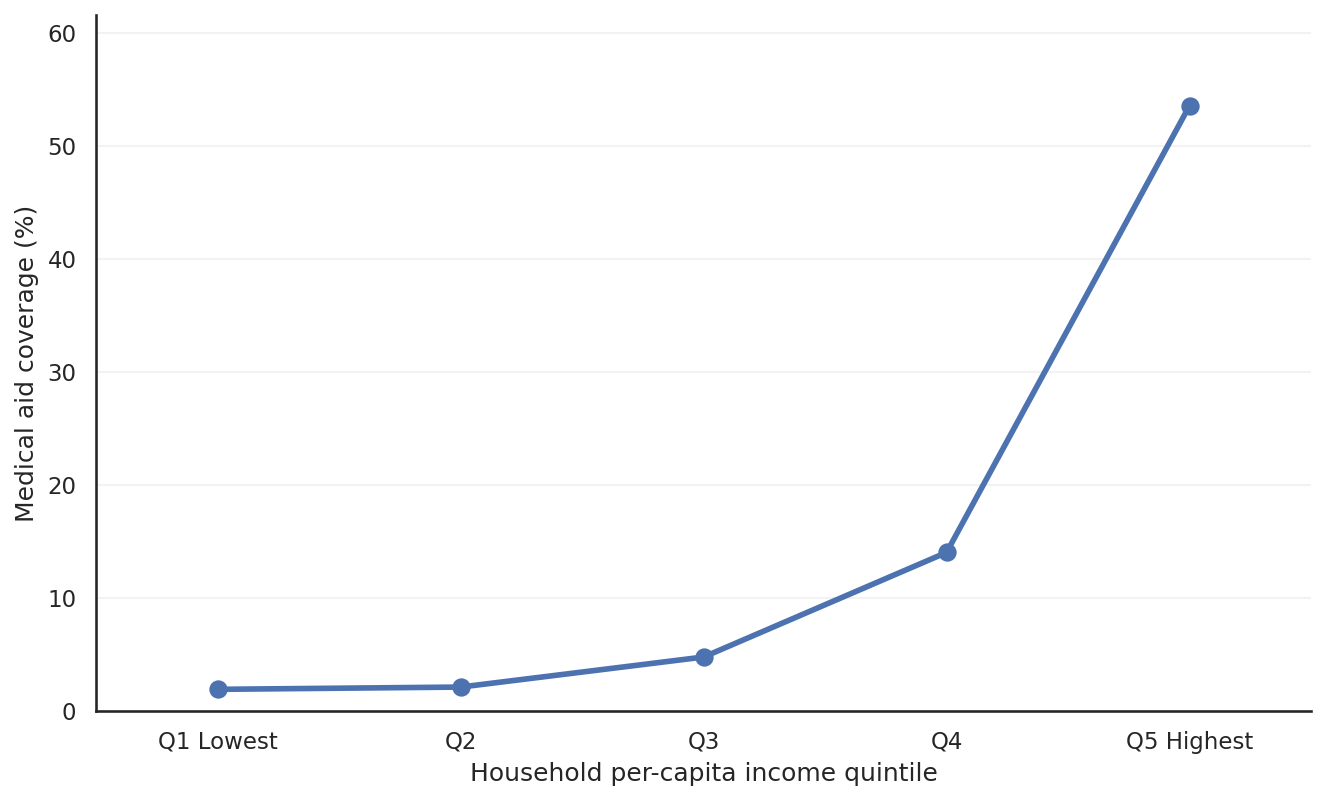

In [98]:
# ============================================================
# MEDICAL AID COVERAGE BY INCOME QUINTILE
# ============================================================

plot_data = medical_aid_income.copy()

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

sns.pointplot(
    data=plot_data,
    x="person_income_quintile",
    y="Weighted_percent",
    ax=ax
)

ax.set_xlabel(
    "Household per-capita income quintile"
)

ax.set_ylabel(
    "Medical aid coverage (%)"
)

ax.set_ylim(
    0,
    max(plot_data["Weighted_percent"]) * 1.15
)

ax.grid(
    axis="y",
    alpha=0.25
)

sns.despine()

plt.tight_layout()

save_figure(
    fig,
    "Medical_Aid_Coverage_by_Income_Quintile"
)

plt.show()

In [99]:
# ============================================================
# VERIFY GEOGRAPHIC TYPE CODING
# ============================================================

print("Raw geotype values:")
print(
    person["geotype"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nData type:")
print(person["geotype"].dtype)

Raw geotype values:
geotype
1    41126
2    24408
3     2214
Name: count, dtype: int64

Data type:
int64


In [100]:
# ============================================================
# MEDICAL AID COVERAGE BY MATERIAL WEALTH
# ============================================================

medical_aid_wealth = weighted_binary_prevalence(
    analysis,
    group="person_wealth_quintile",
    outcome="medical_aid",
    weight="person_wgt"
)

display(
    medical_aid_wealth.round(2)
)

,person_wealth_quintile,Unweighted_n,Weighted_population,Weighted_prevalence,Weighted_percent
0,Q1 Lowest,16093,"13,984,021.650",0.020,1.520
1,Q2,13058,"11,670,812.390",0.030,2.530
2,Q3,14407,"12,767,673.330",0.050,5.050
3,Q4,13461,"12,745,256.670",0.150,14.550
4,Q5 Highest,10604,"12,763,893.260",0.540,54.470


In [101]:
# ============================================================
# COMPARE INCOME AND WEALTH GRADIENTS
# ============================================================

income_plot = (
    medical_aid_income[
        ["person_income_quintile", "Weighted_percent"]
    ]
    .copy()
)

income_plot.columns = [
    "Quintile",
    "Medical_aid_pct"
]

income_plot["SES_measure"] = "Per-capita income"


wealth_plot = (
    medical_aid_wealth[
        ["person_wealth_quintile", "Weighted_percent"]
    ]
    .copy()
)

wealth_plot.columns = [
    "Quintile",
    "Medical_aid_pct"
]

wealth_plot["SES_measure"] = "Material wealth"


ses_comparison = pd.concat(
    [income_plot, wealth_plot],
    ignore_index=True
)

display(ses_comparison)

,Quintile,Medical_aid_pct,SES_measure
0,Q1 Lowest,1.906,Per-capita income
1,Q2,2.106,Per-capita income
2,Q3,4.764,Per-capita income
3,Q4,14.016,Per-capita income
4,Q5 Highest,53.530,Per-capita income
5,Q1 Lowest,1.525,Material wealth
6,Q2,2.526,Material wealth
7,Q3,5.046,Material wealth
8,Q4,14.550,Material wealth
9,Q5 Highest,54.473,Material wealth


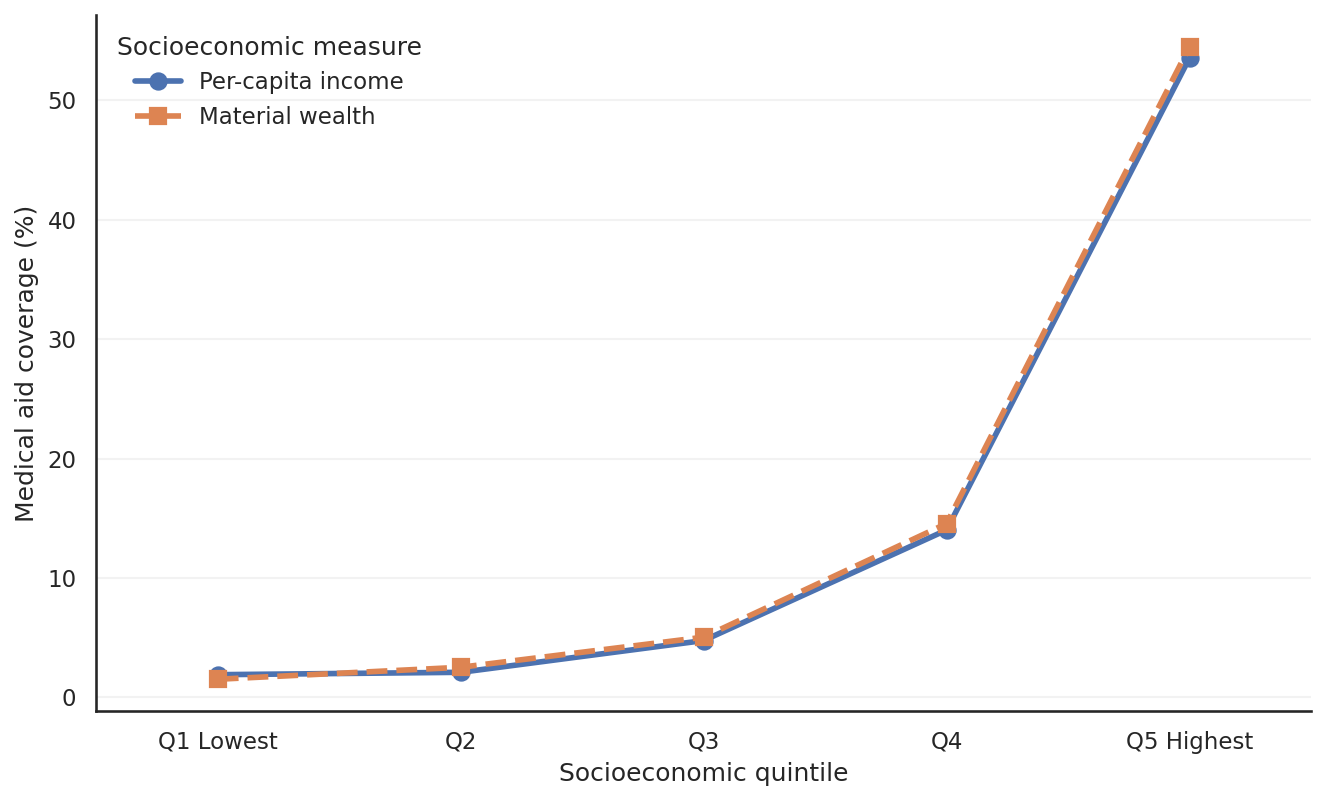

In [102]:
fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

sns.pointplot(
    data=ses_comparison,
    x="Quintile",
    y="Medical_aid_pct",
    hue="SES_measure",
    markers=["o", "s"],
    linestyles=["-", "--"],
    ax=ax
)

ax.set_xlabel("Socioeconomic quintile")
ax.set_ylabel("Medical aid coverage (%)")

ax.legend(
    title="Socioeconomic measure",
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

sns.despine()

plt.tight_layout()

save_figure(
    fig,
    "Medical_Aid_Coverage_Income_vs_Wealth"
)

plt.show()

In [103]:
# ============================================================
# MEDICAL AID COVERAGE BY PROVINCE
# ============================================================

medical_aid_province = weighted_binary_prevalence(
    analysis,
    group="province",
    outcome="medical_aid",
    weight="person_wgt"
)

medical_aid_province = (
    medical_aid_province
    .sort_values(
        "Weighted_percent",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    medical_aid_province.round(2)
)

,province,Unweighted_n,Weighted_population,Weighted_prevalence,Weighted_percent
0,Western Cape,6118,"7,634,941.630",0.260,25.950
1,Gauteng,15673,"17,360,476.930",0.220,22.160
2,Northern Cape,3121,"1,334,171.560",0.170,16.710
3,North West,4248,"4,378,273.990",0.130,13.120
4,Mpumalanga,5460,"5,085,453.190",0.130,12.650
5,Free State,3727,"3,076,162.710",0.120,11.830
6,Eastern Cape,8960,"6,523,428.830",0.100,9.920
7,KwaZulu-Natal,12466,"12,181,480.700",0.100,9.520
8,Limpopo,7850,"6,357,267.760",0.080,8.190


In [104]:
# ============================================================
# MEDICAL AID COVERAGE BY METROPOLITAN STATUS
# ============================================================

medical_aid_metro = weighted_binary_prevalence(
    analysis,
    group="metro_status",
    outcome="medical_aid",
    weight="person_wgt"
)

display(
    medical_aid_metro.round(2)
)

,metro_status,Unweighted_n,Weighted_population,Weighted_prevalence,Weighted_percent
0,Metro,24810,"27,067,354.970",0.230,22.760
1,Non-metro,42813,"36,864,302.330",0.100,10.300


In [105]:
# ============================================================
# MEDICAL AID COVERAGE BY POPULATION GROUP
# ============================================================

medical_aid_population = weighted_binary_prevalence(
    analysis,
    group="population_group",
    outcome="medical_aid",
    weight="person_wgt"
)

medical_aid_population = (
    medical_aid_population
    .sort_values(
        "Weighted_percent",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    medical_aid_population.round(2)
)

,population_group,Unweighted_n,Weighted_population,Weighted_prevalence,Weighted_percent
0,White,3035,"4,259,123.080",0.710,71.470
1,Indian/Asian,1040,"1,559,295.630",0.430,43.180
2,Coloured,5972,"5,402,054.570",0.190,19.260
3,African/Black,57576,"52,711,184.010",0.100,9.870


In [106]:
# ============================================================
# MEDICAL AID COVERAGE BY SEX
# ============================================================

medical_aid_sex = weighted_binary_prevalence(
    analysis,
    group="sex",
    outcome="medical_aid",
    weight="person_wgt"
)

display(
    medical_aid_sex.round(2)
)

,sex,Unweighted_n,Weighted_population,Weighted_prevalence,Weighted_percent
0,Female,35099,"32,580,015.610",0.160,16.050
1,Male,32524,"31,351,641.690",0.150,15.090


In [107]:
# ============================================================
# MEDICAL AID COVERAGE BY AGE GROUP
# ============================================================

medical_aid_age = weighted_binary_prevalence(
    analysis,
    group="age_group",
    outcome="medical_aid",
    weight="person_wgt"
)

display(
    medical_aid_age.round(2)
)

,age_group,Unweighted_n,Weighted_population,Weighted_prevalence,Weighted_percent
0,0–17,22585,"21,041,796.160",0.130,13.070
1,18–34,17917,"17,772,411.960",0.110,11.150
2,35–49,13066,"14,052,033.570",0.180,17.870
3,50–64,8766,"7,167,877.510",0.240,24.250
4,65+,5289,"3,897,538.100",0.250,25.100


In [108]:
# ============================================================
# MEDICAL AID COVERAGE BY FOOD-INSECURITY SCORE
# ============================================================

medical_aid_food = weighted_binary_prevalence(
    analysis,
    group="food_insecurity_score",
    outcome="medical_aid",
    weight="person_wgt"
)

display(
    medical_aid_food.round(2)
)

,food_insecurity_score,Unweighted_n,Weighted_population,Weighted_prevalence,Weighted_percent
0,0.000,44865,"43,696,998.510",0.210,20.590
1,1.000,2575,"2,275,692.760",0.090,9.370
2,2.000,2371,"2,191,023.150",0.100,10.200
3,3.000,2285,"1,953,673.370",0.060,5.550
4,4.000,2236,"1,926,707.880",0.030,3.440
5,5.000,1835,"1,531,119.040",0.040,3.910
6,6.000,2430,"2,110,148.640",0.030,2.740
7,7.000,2829,"2,562,911.340",0.020,2.150
8,8.000,5830,"5,312,611.940",0.020,2.190


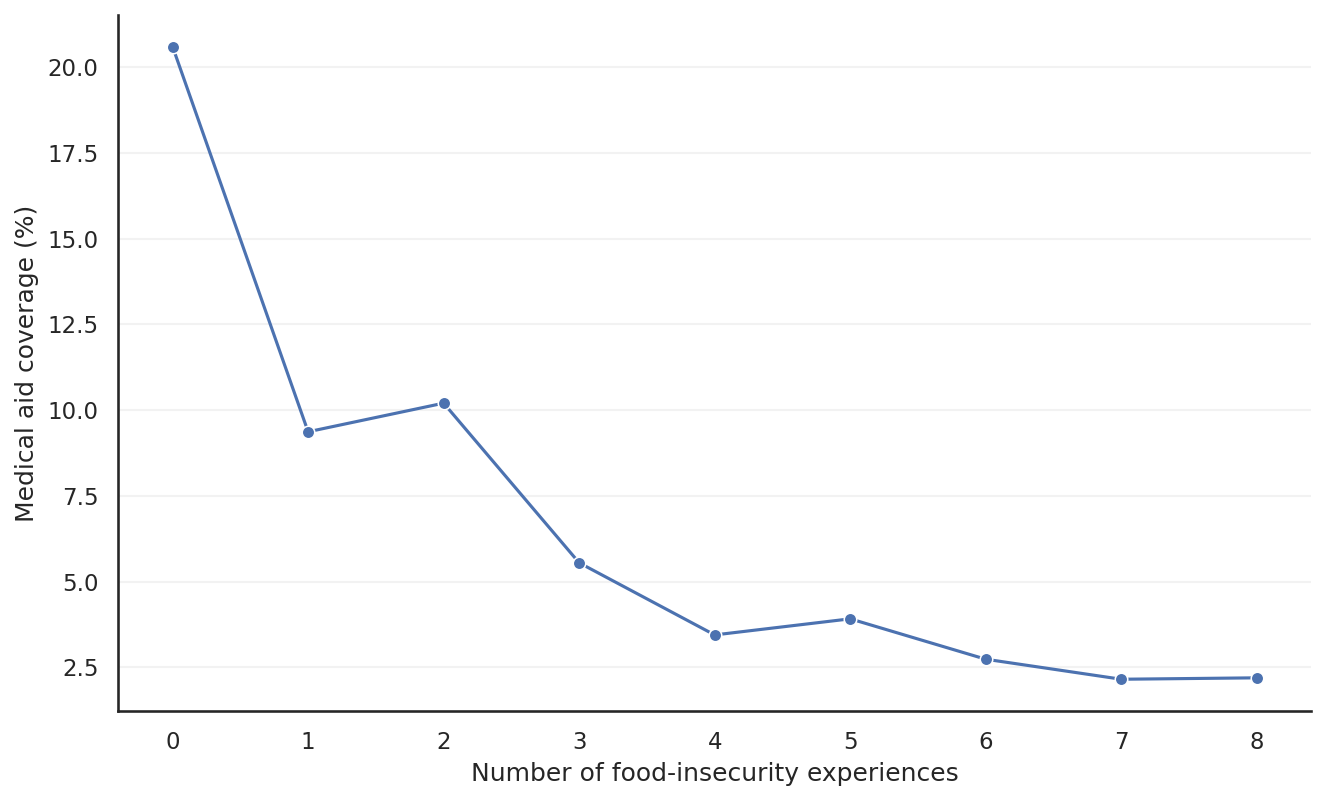

In [109]:
fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

sns.lineplot(
    data=medical_aid_food,
    x="food_insecurity_score",
    y="Weighted_percent",
    marker="o",
    ax=ax
)

ax.set_xlabel(
    "Number of food-insecurity experiences"
)

ax.set_ylabel(
    "Medical aid coverage (%)"
)

ax.grid(
    axis="y",
    alpha=0.25
)

sns.despine()

plt.tight_layout()

save_figure(
    fig,
    "Medical_Aid_Coverage_by_Food_Insecurity"
)

plt.show()

### **Multidimensional Healthcare Access**

Healthcare access was conceptualised as multidimensional rather than represented by a single indicator. Four complementary dimensions were considered:

1. **Financial coverage** — absence of medical aid;
2. **Geographic accessibility** — extended travel time to the nearest healthcare facility;
3. **Transport accessibility** — reliance on walking or shared/public transport;
4. **Health-system context** — household reliance on the public rather than private healthcare sector.

These dimensions are initially examined separately to determine whether socioeconomic and geographic disadvantage operates consistently across different aspects of healthcare access. A cumulative disadvantage measure is considered subsequently only after examining the empirical relationships among the individual dimensions.

In [110]:
# ============================================================
# TRANSPORT ACCESS INDICATOR
# ============================================================

analysis["transport_constraint"] = np.where(
    analysis["transport_group"].notna(),
    analysis["transport_group"].isin([
        "Walking",
        "Public/shared transport"
    ]).astype(int),
    np.nan
)

display(
    weighted_binary_prevalence(
        analysis,
        group="person_income_quintile",
        outcome="transport_constraint",
        weight="person_wgt"
    ).round(2)
)

,person_income_quintile,Unweighted_n,Weighted_population,Weighted_prevalence,Weighted_percent
0,Q1 Lowest,13839,"12,629,024.930",0.950,95.310
1,Q2,15156,"12,600,572.480",0.930,93.310
2,Q3,14554,"12,602,746.010",0.870,87.310
3,Q4,12651,"12,622,697.840",0.710,70.730
4,Q5 Highest,10659,"12,605,757.050",0.270,27.060


In [111]:
# ============================================================
# TRANSPORT ACCESS INDICATOR
# ============================================================

analysis["transport_constraint"] = np.where(
    analysis["transport_group"].notna(),
    analysis["transport_group"].isin([
        "Walking",
        "Public/shared transport"
    ]).astype(int),
    np.nan
)

display(
    weighted_binary_prevalence(
        analysis,
        group="person_income_quintile",
        outcome="transport_constraint",
        weight="person_wgt"
    ).round(2)
)

,person_income_quintile,Unweighted_n,Weighted_population,Weighted_prevalence,Weighted_percent
0,Q1 Lowest,13839,"12,629,024.930",0.950,95.310
1,Q2,15156,"12,600,572.480",0.930,93.310
2,Q3,14554,"12,602,746.010",0.870,87.310
3,Q4,12651,"12,622,697.840",0.710,70.730
4,Q5 Highest,10659,"12,605,757.050",0.270,27.060


In [112]:
# ============================================================
# HIGH TRAVEL BURDEN BY WEALTH QUINTILE
# ============================================================

travel_wealth = weighted_binary_prevalence(
    analysis,
    group="person_wealth_quintile",
    outcome="high_travel_burden",
    weight="person_wgt"
)

display(
    travel_wealth.round(2)
)

,person_wealth_quintile,Unweighted_n,Weighted_population,Weighted_prevalence,Weighted_percent
0,Q1 Lowest,16094,"13,993,048.890",0.250,24.850
1,Q2,13055,"11,663,028.560",0.230,22.660
2,Q3,14418,"12,781,051.960",0.140,13.800
3,Q4,13483,"12,770,854.070",0.110,10.690
4,Q5 Highest,10619,"12,767,127.720",0.070,6.880


In [113]:
# ============================================================
# HIGH TRAVEL BURDEN BY METROPOLITAN STATUS
# ============================================================

travel_metro = weighted_binary_prevalence(
    analysis,
    group="metro_status",
    outcome="high_travel_burden",
    weight="person_wgt"
)

display(
    travel_metro.round(2)
)

,metro_status,Unweighted_n,Weighted_population,Weighted_prevalence,Weighted_percent
0,Metro,24837,"27,078,473.720",0.060,6.000
1,Non-metro,42832,"36,896,637.480",0.230,23.050


In [114]:
# ============================================================
# INTERSECTION OF INCOME AND METROPOLITAN STATUS
# ============================================================

income_metro_travel = (
    analysis[
        analysis["person_income_quintile"].notna() &
        analysis["metro_status"].notna() &
        analysis["high_travel_burden"].notna()
    ]
    .groupby(
        [
            "person_income_quintile",
            "metro_status"
        ],
        observed=True
    )
    .apply(
        lambda x: pd.Series({
            "Unweighted_n": len(x),

            "Weighted_population":
                x["person_wgt"].sum(),

            "High_travel_burden_pct":
                np.average(
                    x["high_travel_burden"],
                    weights=x["person_wgt"]
                ) * 100
        }),
        include_groups=False
    )
    .reset_index()
)

display(
    income_metro_travel.round(2)
)

,person_income_quintile,metro_status,Unweighted_n,Weighted_population,High_travel_burden_pct
0,Q1 Lowest,Metro,"3,360.000","3,111,282.360",8.580
1,Q1 Lowest,Non-metro,"10,470.000","9,507,892.200",31.120
2,Q2,Metro,"3,784.000","3,601,220.940",6.130
3,Q2,Non-metro,"11,356.000","8,988,670.240",27.320
4,Q3,Metro,"5,311.000","5,140,882.960",7.220
5,Q3,Non-metro,"9,225.000","7,449,864.660",21.130
6,Q4,Metro,"6,046.000","6,633,883.330",5.280
7,Q4,Non-metro,"6,599.000","5,981,529.360",15.070
8,Q5 Highest,Metro,"5,856.000","8,016,878.240",4.920
9,Q5 Highest,Non-metro,"4,795.000","4,579,104.390",11.320


In [115]:
# ============================================================
# MEDICAL AID: INCOME × METROPOLITAN STATUS
# ============================================================

income_metro_medical = (
    analysis[
        analysis["person_income_quintile"].notna() &
        analysis["metro_status"].notna() &
        analysis["medical_aid"].notna()
    ]
    .groupby(
        [
            "person_income_quintile",
            "metro_status"
        ],
        observed=True
    )
    .apply(
        lambda x: pd.Series({
            "Unweighted_n": len(x),

            "Weighted_population":
                x["person_wgt"].sum(),

            "Medical_aid_pct":
                np.average(
                    x["medical_aid"],
                    weights=x["person_wgt"]
                ) * 100
        }),
        include_groups=False
    )
    .reset_index()
)

display(
    income_metro_medical.round(2)
)

,person_income_quintile,metro_status,Unweighted_n,Weighted_population,Medical_aid_pct
0,Q1 Lowest,Metro,"3,373.000","3,131,767.150",3.570
1,Q1 Lowest,Non-metro,"10,461.000","9,497,304.500",1.360
2,Q2,Metro,"3,780.000","3,597,903.700",2.940
3,Q2,Non-metro,"11,362.000","8,991,281.960",1.770
4,Q3,Metro,"5,300.000","5,129,504.990",6.020
5,Q3,Non-metro,"9,226.000","7,444,885.660",3.900
6,Q4,Metro,"6,028.000","6,613,899.350",14.700
7,Q4,Non-metro,"6,585.000","5,966,907.880",13.260
8,Q5 Highest,Metro,"5,841.000","7,995,450.520",55.280
9,Q5 Highest,Non-metro,"4,790.000","4,572,621.600",50.480


In [116]:
# ============================================================
# MULTIDIMENSIONAL ACCESS PROFILE BY INCOME
# ============================================================

def weighted_pct(subset, variable):

    valid = subset[
        subset[variable].notna() &
        subset["person_wgt"].notna()
    ]

    if len(valid) == 0:
        return np.nan

    return (
        np.average(
            valid[variable],
            weights=valid["person_wgt"]
        ) * 100
    )


access_profile = []

for quintile, subset in analysis.groupby(
    "person_income_quintile",
    observed=True
):

    access_profile.append({

        "Income_quintile": quintile,

        "No_medical_aid_pct":
            weighted_pct(
                subset,
                "no_medical_aid"
            ),

        "High_travel_burden_pct":
            weighted_pct(
                subset,
                "high_travel_burden"
            ),

        "Walking_or_shared_transport_pct":
            weighted_pct(
                subset,
                "transport_constraint"
            )
    })


access_profile = pd.DataFrame(
    access_profile
)

display(
    access_profile.round(2)
)

,Income_quintile,No_medical_aid_pct,High_travel_burden_pct,Walking_or_shared_transport_pct
0,Q1 Lowest,98.090,25.560,95.310
1,Q2,97.890,21.260,93.310
2,Q3,95.240,15.450,87.310
3,Q4,85.980,9.920,70.730
4,Q5 Highest,46.470,7.250,27.060


In [117]:
# ============================================================
# FINAL ANALYTICAL DATASET VALIDATION
# ============================================================

print("=" * 70)
print("FINAL GHS 2025 ANALYTICAL DATASET")
print("=" * 70)

print(f"Individuals: {len(analysis):,}")
print(f"Households: {analysis['uqnr'].nunique():,}")
print(f"Variables: {analysis.shape[1]:,}")

print("\nSurvey design:")
print(f"PSUs: {analysis['psu'].nunique():,}")
print(f"Strata: {analysis['stratum'].nunique():,}")
print(f"Provinces: {analysis['province'].nunique():,}")

print("\nKey outcomes:")

for var in [
    "medical_aid",
    "no_medical_aid",
    "high_travel_burden",
    "transport_constraint"
]:
    print(
        f"{var}: "
        f"{analysis[var].notna().sum():,} valid "
        f"({analysis[var].notna().mean()*100:.2f}%)"
    )

print("\nKey SES variables:")

for var in [
    "person_income_quintile",
    "person_wealth_quintile",
    "food_insecurity_score",
    "education_group",
    "employment_status"
]:
    print(
        f"{var}: "
        f"{analysis[var].notna().sum():,} valid "
        f"({analysis[var].notna().mean()*100:.2f}%)"
    )

print("\nDuplicate person records:")
print(analysis.duplicated().sum())

FINAL GHS 2025 ANALYTICAL DATASET
Individuals: 67,748
Households: 20,095
Variables: 158

Survey design:
PSUs: 3,226
Strata: 248
Provinces: 9

Key outcomes:
medical_aid: 67,623 valid (99.82%)
no_medical_aid: 67,623 valid (99.82%)
high_travel_burden: 67,669 valid (99.88%)
transport_constraint: 67,738 valid (99.99%)

Key SES variables:
person_income_quintile: 66,869 valid (98.70%)
person_wealth_quintile: 67,748 valid (100.00%)
food_insecurity_score: 67,380 valid (99.46%)
education_group: 66,753 valid (98.53%)
employment_status: 49,234 valid (72.67%)

Duplicate person records:
0


In [118]:
# ============================================================
# SAVE ANALYSIS-READY DATASET
# ============================================================

output_file = "ghs2025_healthcare_analysis.csv"

analysis.to_csv(
    output_file,
    index=False,
    encoding="utf-8"
)

print(
    f"Analysis-ready dataset saved:\n"
    f"{output_file}"
)

print(
    f"\nShape: "
    f"{analysis.shape[0]:,} rows × "
    f"{analysis.shape[1]:,} columns"
)

Analysis-ready dataset saved:
ghs2025_healthcare_analysis.csv

Shape: 67,748 rows × 158 columns


### **Analytical Dataset**

Following data cleaning, household–person linkage, survey-design validation, variable recoding, socioeconomic measure construction, and exploratory analysis, the final person-level analytical dataset was exported for formal statistical and machine-learning analysis.

The exploratory analysis demonstrated substantial variation across multiple dimensions of healthcare access, including medical aid coverage, travel burden and transport accessibility. These preliminary patterns were used to validate the analytical constructs rather than as formal inferential results.

All subsequent survey-adjusted inequality estimation, multivariable modelling, intersectional analysis and machine-learning experiments are conducted in a separate modelling notebook.